In [2]:
#%pip install scipy
#%pip install tensorflow
#%pip install pandas
#%pip install seaborn
#%pip install numpy
#%pip install scikit-learn
#%pip install matplotlib
#%pip install python-chess

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import chess
import random
import re

#imports for transformed model
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, make_scorer
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, train_test_split, cross_val_score, GroupKFold
from sklearn.utils.class_weight import compute_class_weight


#tensorflow imports for transformer model
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.layers import TextVectorization, Embedding, Dense, MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D, Dropout, Concatenate

In [3]:
random.seed(42)
np.random.seed(42)


# -------------------------------
# 1. Load Dataset
# -------------------------------

DATASET_PATH = "dataset_"

with open(DATASET_PATH, "r") as f:
    lines = f.readlines()

data_start = next(i for i, line in enumerate(lines) if "@DATA" in line)

dataset = pd.read_csv(DATASET_PATH, skiprows=data_start + 1, header=None)

dataset.columns = [
    "id", "rated", "created_at", "last_move_at", "turns",
    "victory_status", "winner", "increment_code",
    "white_id", "white_rating", "black_id", "black_rating",
    "moves", "opening_eco", "opening_name", "opening_ply"
]


# -------------------------------
# 2. Basic Feature Engineering BEFORE Split
# -------------------------------

dataset["moves_clean"] = dataset["moves"].astype(str).str.strip().str.strip("'")

# Rating features
dataset["rating_diff"] = dataset["white_rating"] - dataset["black_rating"]
dataset["rating_abs_diff"] = dataset["rating_diff"].abs()
dataset["white_higher_rated"] = (dataset["white_rating"] > dataset["black_rating"]).astype(int)

# Time control features
dataset[["base_time", "time_increment"]] = dataset["increment_code"].astype(str).str.split("+", expand=True)
dataset["base_time"] = dataset["base_time"].astype(int)
dataset["time_increment"] = dataset["time_increment"].astype(int)

# Opening features
dataset["opening_letter"] = dataset["opening_eco"].astype(str).str[0]
dataset["opening_number"] = dataset["opening_eco"].astype(str).str.extract(r"([0-9]{2})")[0].astype(int)
dataset["opening_number_bucket"] = (dataset["opening_number"] // 10).astype(int)
dataset["opening_tens_digit"] = (dataset["opening_number"] // 10).astype(int)
dataset["opening_ones_digit"] = (dataset["opening_number"] % 10).astype(int)
dataset["opening_ply"] = dataset["opening_ply"].astype(int)

# Rated feature
dataset["rated"] = dataset["rated"].astype(str).str.lower().map({"true": 1, "false": 0}).astype(int)


# -------------------------------
# 3. Player Features BEFORE Split
# -------------------------------

def extract_name_features(name):
    name = str(name)

    length = len(name)
    has_number = int(any(c.isdigit() for c in name))

    numbers = re.findall(r"\d+", name)
    numbers = [int(n) for n in numbers]

    age_like = int(any(10 <= n <= 2000 for n in numbers))

    return length, has_number, age_like


def add_player_features(df):
    df = df.copy()

    white_features = pd.DataFrame(
        df["white_id"].apply(extract_name_features).tolist(),
        columns=["white_name_length", "white_has_number", "white_age_like"],
        index=df.index
    )

    black_features = pd.DataFrame(
        df["black_id"].apply(extract_name_features).tolist(),
        columns=["black_name_length", "black_has_number", "black_age_like"],
        index=df.index
    )

    return pd.concat([df, white_features, black_features], axis=1)


def is_daytime(timestamp):
    hour = pd.to_datetime(timestamp, unit="s").hour
    return int(8 <= hour < 20)


dataset = add_player_features(dataset)

dataset["is_daytime"] = dataset["created_at"].apply(is_daytime)
dataset["is_night"] = 1 - dataset["is_daytime"]


# -------------------------------
# 4. Encode Targets BEFORE Split
# -------------------------------

winner_encoder = LabelEncoder()
status_encoder = LabelEncoder()

dataset["y_winner"] = winner_encoder.fit_transform(dataset["winner"])
dataset["y_status"] = status_encoder.fit_transform(dataset["victory_status"])

print("Winner classes:", list(winner_encoder.classes_))
print("Status classes:", list(status_encoder.classes_))


# -------------------------------
# 5. Train/Test Split BEFORE Snapshot Expansion
# -------------------------------

train_df, test_df = train_test_split(
    dataset,
    test_size=0.2,
    random_state=42,
    stratify=dataset["y_winner"]
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)


# -------------------------------
# 6. Create Game Snapshots
# -------------------------------

def make_snapshot_by_moves(move_string, move_cutoff):
    moves = str(move_string).split()

    if len(moves) == 0:
        board = chess.Board()
        return "", board.fen(), 0

    cutoff = min(move_cutoff, len(moves))
    partial_moves = moves[:cutoff]

    board = chess.Board()

    try:
        for move in partial_moves:
            board.push_san(move)

        # Prevent terminal leakage
        if board.is_game_over() and len(partial_moves) > 1:
            partial_moves = partial_moves[:-1]
            board = chess.Board()
            for move in partial_moves:
                board.push_san(move)

        truncated_moves = " ".join(partial_moves)
        fen = board.fen()

    except Exception:
        board = chess.Board()
        truncated_moves = ""
        fen = board.fen()
        partial_moves = []

    return truncated_moves, fen, len(partial_moves)

def expand_games_by_increment(df, increment):
    expanded_rows = []

    for _, row in df.iterrows():
        row_dict = row.to_dict()
        moves = str(row_dict["moves_clean"]).split()
        num_moves = len(moves)

        checkpoints = list(range(increment, num_moves, increment))

        for move_cutoff in checkpoints:
            truncated_moves, fen, num_moves_used = make_snapshot_by_moves(
                row_dict["moves_clean"],
                move_cutoff
            )

            new_row = row_dict.copy()
            new_row["moves_truncated"] = truncated_moves
            new_row["fen"] = fen
            new_row["num_moves_used"] = num_moves_used

            expanded_rows.append(new_row)

    return pd.DataFrame(expanded_rows).reset_index(drop=True)


increment = 5

train_expanded = expand_games_by_increment(train_df, increment)
test_expanded = expand_games_by_increment(test_df, increment)


# -------------------------------
# 7. FEN / Board Feature Extraction
# -------------------------------

PIECE_VALUES = {
    chess.PAWN: 1,
    chess.KNIGHT: 3,
    chess.BISHOP: 3,
    chess.ROOK: 5,
    chess.QUEEN: 9,
    chess.KING: 0
}

CENTER_SQUARES = [chess.D4, chess.E4, chess.D5, chess.E5]


def same_file(sq1, sq2):
    return chess.square_file(sq1) == chess.square_file(sq2)


def same_rank(sq1, sq2):
    return chess.square_rank(sq1) == chess.square_rank(sq2)


def same_diagonal(sq1, sq2):
    return abs(chess.square_file(sq1) - chess.square_file(sq2)) == \
           abs(chess.square_rank(sq1) - chess.square_rank(sq2))


def is_clear_vertical(board, sq1, sq2):
    file_ = chess.square_file(sq1)
    r1 = chess.square_rank(sq1)
    r2 = chess.square_rank(sq2)

    step = 1 if r2 > r1 else -1

    for r in range(r1 + step, r2, step):
        if board.piece_at(chess.square(file_, r)) is not None:
            return False

    return True

def is_clear_diagonal(board, sq1, sq2):
    f1 = chess.square_file(sq1)
    r1 = chess.square_rank(sq1)
    f2 = chess.square_file(sq2)
    r2 = chess.square_rank(sq2)

    if abs(f1 - f2) != abs(r1 - r2):
        return False

    file_step = 1 if f2 > f1 else -1
    rank_step = 1 if r2 > r1 else -1

    f = f1 + file_step
    r = r1 + rank_step

    while f != f2 and r != r2:
        if board.piece_at(chess.square(f, r)) is not None:
            return False

        f += file_step
        r += rank_step

    return True

def count_rook_batteries(board, color):
    rooks = list(board.pieces(chess.ROOK, color))
    count = 0

    for i in range(len(rooks)):
        for j in range(i + 1, len(rooks)):
            sq1 = rooks[i]
            sq2 = rooks[j]

            # Same file
            if chess.square_file(sq1) == chess.square_file(sq2):
                # Check path is clear
                if is_clear_vertical(board, sq1, sq2):
                    count += 1

    return count


def count_queen_rook_batteries(board, color):
    rooks = list(board.pieces(chess.ROOK, color))
    queens = list(board.pieces(chess.QUEEN, color))

    count = 0

    for rook in rooks:
        for queen in queens:
            # Same file
            if chess.square_file(rook) == chess.square_file(queen):
                if is_clear_vertical(board, rook, queen):
                    count += 1

    return count


def count_bishop_queen_batteries(board, color):
    queens = list(board.pieces(chess.QUEEN, color))
    bishops = list(board.pieces(chess.BISHOP, color))
    count = 0

    for q in queens:
        for b in bishops:
            if same_diagonal(q, b) and is_clear_diagonal(board, q, b):
                count += 1

    return count


def has_alekhines_gun(board, color):
    rooks = list(board.pieces(chess.ROOK, color))
    queens = list(board.pieces(chess.QUEEN, color))

    if len(rooks) < 2 or len(queens) < 1:
        return False

    pieces = rooks + queens

    # Check same file
    files = [chess.square_file(sq) for sq in pieces]

    for f in set(files):
        aligned = [sq for sq in pieces if chess.square_file(sq) == f]

        if len(aligned) >= 3:
            # Now check if no pieces block between them
            aligned_sorted = sorted(aligned, key=lambda sq: chess.square_rank(sq))

            clear = True
            for i in range(len(aligned_sorted) - 1):
                if not is_clear_vertical(board, aligned_sorted[i], aligned_sorted[i+1]):
                    clear = False
                    break

            if clear:
                return True

    return False


def count_central_knights(board, color):
    central_squares = {
        chess.C3, chess.D3, chess.E3, chess.F3,
        chess.C4, chess.D4, chess.E4, chess.F4,
        chess.C5, chess.D5, chess.E5, chess.F5,
        chess.C6, chess.D6, chess.E6, chess.F6,
    }

    return sum(1 for k in board.pieces(chess.KNIGHT, color) if k in central_squares)


def count_doubled_pawns(board, color):
    files = []

    for square, piece in board.piece_map().items():
        if piece.color == color and piece.piece_type == chess.PAWN:
            files.append(chess.square_file(square))

    return sum(files.count(f) > 1 for f in set(files))


def count_isolated_pawns(board, color):
    pawn_files = set()

    for square, piece in board.piece_map().items():
        if piece.color == color and piece.piece_type == chess.PAWN:
            pawn_files.add(chess.square_file(square))

    isolated = 0

    for f in pawn_files:
        if (f - 1 not in pawn_files) and (f + 1 not in pawn_files):
            isolated += 1

    return isolated


def fen_to_features(fen):
    board = chess.Board(fen)
    piece_map = board.piece_map()
    features = {}

    # Side to move
    features["white_to_move"] = int(board.turn == chess.WHITE)
    features["black_to_move"] = int(board.turn == chess.BLACK)

    # Castling rights
    features["white_can_castle_kingside"] = int(board.has_kingside_castling_rights(chess.WHITE))
    features["white_can_castle_queenside"] = int(board.has_queenside_castling_rights(chess.WHITE))
    features["black_can_castle_kingside"] = int(board.has_kingside_castling_rights(chess.BLACK))
    features["black_can_castle_queenside"] = int(board.has_queenside_castling_rights(chess.BLACK))

    # En passant / move counters
    features["has_en_passant"] = int(board.ep_square is not None)
    features["halfmove_clock"] = board.halfmove_clock
    features["fullmove_number"] = board.fullmove_number

    # Tactical / positional formations
    features["white_rook_batteries"] = count_rook_batteries(board, chess.WHITE)
    features["black_rook_batteries"] = count_rook_batteries(board, chess.BLACK)
    features["rook_battery_diff"] = features["white_rook_batteries"] - features["black_rook_batteries"]

    features["white_qr_batteries"] = count_queen_rook_batteries(board, chess.WHITE)
    features["black_qr_batteries"] = count_queen_rook_batteries(board, chess.BLACK)
    features["qr_battery_diff"] = features["white_qr_batteries"] - features["black_qr_batteries"]

    features["white_bq_batteries"] = count_bishop_queen_batteries(board, chess.WHITE)
    features["black_bq_batteries"] = count_bishop_queen_batteries(board, chess.BLACK)
    features["bq_battery_diff"] = features["white_bq_batteries"] - features["black_bq_batteries"]

    features["white_alekhines_gun"] = has_alekhines_gun(board, chess.WHITE)
    features["black_alekhines_gun"] = has_alekhines_gun(board, chess.BLACK)
    features["alekhines_gun_diff"] = features["white_alekhines_gun"] - features["black_alekhines_gun"]

    features["white_central_knights"] = count_central_knights(board, chess.WHITE)
    features["black_central_knights"] = count_central_knights(board, chess.BLACK)
    features["central_knight_diff"] = features["white_central_knights"] - features["black_central_knights"]

    # Check state and mobility
    features["side_to_move_in_check"] = int(board.is_check())
    features["num_legal_moves"] = len(list(board.legal_moves))

    # Material and piece counts
    white_material = 0
    black_material = 0

    for piece_type in PIECE_VALUES:
        white_count = len(board.pieces(piece_type, chess.WHITE))
        black_count = len(board.pieces(piece_type, chess.BLACK))
        piece_name = chess.piece_name(piece_type)

        features[f"white_{piece_name}s"] = white_count
        features[f"black_{piece_name}s"] = black_count
        features[f"{piece_name}_diff"] = white_count - black_count

        white_material += white_count * PIECE_VALUES[piece_type]
        black_material += black_count * PIECE_VALUES[piece_type]

    features["white_material"] = white_material
    features["black_material"] = black_material
    features["material_diff"] = white_material - black_material
    features["material_abs_diff"] = abs(white_material - black_material)

    features["white_total_pieces"] = sum(1 for p in piece_map.values() if p.color == chess.WHITE)
    features["black_total_pieces"] = sum(1 for p in piece_map.values() if p.color == chess.BLACK)
    features["piece_count_diff"] = features["white_total_pieces"] - features["black_total_pieces"]

    # Center control
    white_center_control = 0
    black_center_control = 0

    for sq in CENTER_SQUARES:
        white_center_control += len(board.attackers(chess.WHITE, sq))
        black_center_control += len(board.attackers(chess.BLACK, sq))

    features["white_center_control"] = white_center_control
    features["black_center_control"] = black_center_control
    features["center_control_diff"] = white_center_control - black_center_control

    # King safety proxy
    white_king_sq = board.king(chess.WHITE)
    black_king_sq = board.king(chess.BLACK)

    features["white_king_attackers"] = (
        len(board.attackers(chess.BLACK, white_king_sq))
        if white_king_sq is not None else 0
    )

    features["black_king_attackers"] = (
        len(board.attackers(chess.WHITE, black_king_sq))
        if black_king_sq is not None else 0
    )

    features["king_attackers_diff"] = (
        features["black_king_attackers"] - features["white_king_attackers"]
    )

    # Pawn structure
    features["white_doubled_pawns"] = count_doubled_pawns(board, chess.WHITE)
    features["black_doubled_pawns"] = count_doubled_pawns(board, chess.BLACK)
    features["doubled_pawn_diff"] = features["white_doubled_pawns"] - features["black_doubled_pawns"]

    features["white_isolated_pawns"] = count_isolated_pawns(board, chess.WHITE)
    features["black_isolated_pawns"] = count_isolated_pawns(board, chess.BLACK)
    features["isolated_pawn_diff"] = features["white_isolated_pawns"] - features["black_isolated_pawns"]

    return features

def current_strategy_state(board, color):
    return {
        "rook_battery": int(count_rook_batteries(board, color) > 0),
        "qr_battery": int(count_queen_rook_batteries(board, color) > 0),
        "bq_battery": int(count_bishop_queen_batteries(board, color) > 0),
        "alekhines_gun": int(has_alekhines_gun(board, color)),
        "strong_center_knights": int(count_central_knights(board, color) >= 2),
    }

def compute_ever_strategy_features_by_moves(move_string, move_cutoff):
    moves = str(move_string).split()
    cutoff = min(move_cutoff, len(moves))

    history = {
        "white_ever_rook_battery": 0,
        "black_ever_rook_battery": 0,
        "white_ever_qr_battery": 0,
        "black_ever_qr_battery": 0,
        "white_ever_bq_battery": 0,
        "black_ever_bq_battery": 0,
        "white_ever_alekhines_gun": 0,
        "black_ever_alekhines_gun": 0,
        "white_ever_strong_center_knights": 0,
        "black_ever_strong_center_knights": 0,
    }

    board = chess.Board()

    try:
        for i in range(cutoff):
            board.push_san(moves[i])

            white_state = current_strategy_state(board, chess.WHITE)
            black_state = current_strategy_state(board, chess.BLACK)

            for key in white_state:
                if white_state[key]:
                    history[f"white_ever_{key}"] = 1

                if black_state[key]:
                    history[f"black_ever_{key}"] = 1

    except Exception:
        pass

    return history


def compute_strategy_history_features_by_moves(move_string, move_cutoff, window=10):
    moves = str(move_string).split()
    cutoff = min(move_cutoff, len(moves))
    start = max(0, cutoff - window)

    history = {
        "white_recent_rook_battery": 0,
        "black_recent_rook_battery": 0,
        "white_recent_qr_battery": 0,
        "black_recent_qr_battery": 0,
        "white_recent_bq_battery": 0,
        "black_recent_bq_battery": 0,
        "white_recent_alekhines_gun": 0,
        "black_recent_alekhines_gun": 0,
        "white_recent_strong_center_knights": 0,
        "black_recent_strong_center_knights": 0,

        "white_recent_rook_battery_count": 0,
        "black_recent_rook_battery_count": 0,
        "white_recent_qr_battery_count": 0,
        "black_recent_qr_battery_count": 0,
        "white_recent_bq_battery_count": 0,
        "black_recent_bq_battery_count": 0,
        "white_recent_alekhines_gun_count": 0,
        "black_recent_alekhines_gun_count": 0,
        "white_recent_strong_center_knight_count": 0,
        "black_recent_strong_center_knight_count": 0,
    }

    board = chess.Board()

    try:
        for i in range(start):
            board.push_san(moves[i])

        prev_white = current_strategy_state(board, chess.WHITE)
        prev_black = current_strategy_state(board, chess.BLACK)

        for i in range(start, cutoff):
            board.push_san(moves[i])

            curr_white = current_strategy_state(board, chess.WHITE)
            curr_black = current_strategy_state(board, chess.BLACK)

            for key in curr_white:
                if curr_white[key]:
                    history[f"white_recent_{key}"] = 1

                if curr_black[key]:
                    history[f"black_recent_{key}"] = 1

                # count only new appearances, not persistent states
                if curr_white[key] and not prev_white[key]:
                    count_name = f"white_recent_{key}_count"
                    if key == "strong_center_knights":
                        count_name = "white_recent_strong_center_knight_count"
                    history[count_name] += 1

                if curr_black[key] and not prev_black[key]:
                    count_name = f"black_recent_{key}_count"
                    if key == "strong_center_knights":
                        count_name = "black_recent_strong_center_knight_count"
                    history[count_name] += 1

            prev_white = curr_white
            prev_black = curr_black

    except Exception:
        pass

    return history


def add_fen_features(df):
    fen_feature_df = pd.DataFrame([fen_to_features(fen) for fen in df["fen"]])
    return pd.concat([df.reset_index(drop=True), fen_feature_df.reset_index(drop=True)], axis=1)

def add_strategy_history_features(df, window=10):
    history_df = pd.DataFrame([
        compute_strategy_history_features_by_moves(
            row["moves_clean"],
            row["num_moves_used"],
            window=window
        )
        for _, row in df.iterrows()
    ])

    return pd.concat([df.reset_index(drop=True), history_df.reset_index(drop=True)], axis=1)

def add_ever_strategy_features(df):
    ever_df = pd.DataFrame([
        compute_ever_strategy_features_by_moves(
            row["moves_clean"],
            row["num_moves_used"]
        )
        for _, row in df.iterrows()
    ])

    return pd.concat([df.reset_index(drop=True), ever_df.reset_index(drop=True)], axis=1)


train_expanded = add_fen_features(train_expanded)
test_expanded = add_fen_features(test_expanded)

train_expanded = add_strategy_history_features(train_expanded, window=10)
test_expanded = add_strategy_history_features(test_expanded, window=10)

train_expanded = add_ever_strategy_features(train_expanded)
test_expanded = add_ever_strategy_features(test_expanded)


# -------------------------------
# 8. One-Hot ECO Features AFTER Expansion
# -------------------------------

eco_letter_categories = ["A", "B", "C", "D", "E"]
eco_bucket_categories = list(range(10))

train_expanded["opening_letter"] = pd.Categorical(
    train_expanded["opening_letter"],
    categories=eco_letter_categories
)

test_expanded["opening_letter"] = pd.Categorical(
    test_expanded["opening_letter"],
    categories=eco_letter_categories
)

train_expanded["opening_number_bucket"] = pd.Categorical(
    train_expanded["opening_number_bucket"],
    categories=eco_bucket_categories
)

test_expanded["opening_number_bucket"] = pd.Categorical(
    test_expanded["opening_number_bucket"],
    categories=eco_bucket_categories
)

train_eco_letter = pd.get_dummies(train_expanded["opening_letter"], prefix="eco_letter")
test_eco_letter = pd.get_dummies(test_expanded["opening_letter"], prefix="eco_letter")

train_eco_bucket = pd.get_dummies(train_expanded["opening_number_bucket"], prefix="eco_bucket")
test_eco_bucket = pd.get_dummies(test_expanded["opening_number_bucket"], prefix="eco_bucket")

train_expanded = pd.concat([train_expanded, train_eco_letter, train_eco_bucket], axis=1)
test_expanded = pd.concat([test_expanded, test_eco_letter, test_eco_bucket], axis=1)


# -------------------------------
# 9. Final Feature Columns
# -------------------------------

base_feature_cols = [
    "rated",
    "white_rating",
    "black_rating",
    "rating_diff",
    "rating_abs_diff",
    "white_higher_rated",
    "base_time",
    "time_increment",
    "opening_ply",
    "opening_number",
    "opening_tens_digit",
    "opening_ones_digit",
    "num_moves_used"
]

player_feature_cols = [
    "white_name_length",
    "white_has_number",
    "white_age_like",
    "black_name_length",
    "black_has_number",
    "black_age_like",
    "is_daytime",
    "is_night"
]

excluded_cols = set(dataset.columns).union({
    "moves_truncated",
    "fen",
    "num_moves_used"
})

fen_feature_cols = [
    col for col in train_expanded.columns
    if col not in excluded_cols
    and not col.startswith("eco_letter_")
    and not col.startswith("eco_bucket_")
]

eco_cols = [
    col for col in train_expanded.columns
    if col.startswith("eco_letter_") or col.startswith("eco_bucket_")
]

feature_cols = list(dict.fromkeys(
    base_feature_cols +
    player_feature_cols +
    fen_feature_cols +
    eco_cols
))


# -------------------------------
# 10. Final Model Inputs / Outputs
# -------------------------------

X_train_global = train_expanded[feature_cols].astype(float)
X_test_global = test_expanded[feature_cols].astype(float)

y_winner_train = train_expanded["winner"]
y_winner_test = test_expanded["winner"]

y_status_train = train_expanded["victory_status"]
y_status_test = test_expanded["victory_status"]

y_winner_train_encoded = train_expanded["y_winner"].values
y_winner_test_encoded = test_expanded["y_winner"].values

y_status_train_encoded = train_expanded["y_status"].values
y_status_test_encoded = test_expanded["y_status"].values


# -------------------------------
# 11. Sanity Checks
# -------------------------------

print("\nOriginal training games:", len(train_df))
print("Expanded training snapshots:", len(train_expanded))
print("Original testing games:", len(test_df))
print("Expanded testing snapshots:", len(test_expanded))

print("\nNumber of global features:", len(feature_cols))
print("X_train_global shape:", X_train_global.shape)
print("X_test_global shape:", X_test_global.shape)

print("\nExample truncated moves:")
print(train_expanded.loc[0, "moves_truncated"])

print("\nExample FEN:")
print(train_expanded.loc[0, "fen"])

print("\nFirst 30 feature columns:")
print(feature_cols[:30])

print("\nNew feature checks:")
print([
    col for col in feature_cols
    if "battery" in col
    or "alek" in col
    or "central_knight" in col
    or "name" in col
    or "age_like" in col
    or "day" in col
    or "night" in col
    or "opening_number" in col
])



Winner classes: ['black', 'draw', 'white']
Status classes: ['draw', 'mate', 'outoftime', 'resign']

Original training games: 16046
Expanded training snapshots: 184180
Original testing games: 4012
Expanded testing snapshots: 46350

Number of global features: 129
X_train_global shape: (184180, 129)
X_test_global shape: (46350, 129)

Example truncated moves:
e4 e6 b3 d5 f3

Example FEN:
rnbqkbnr/ppp2ppp/4p3/3p4/4P3/1P3P2/P1PP2PP/RNBQKBNR b KQkq - 0 3

First 30 feature columns:
['rated', 'white_rating', 'black_rating', 'rating_diff', 'rating_abs_diff', 'white_higher_rated', 'base_time', 'time_increment', 'opening_ply', 'opening_number', 'opening_tens_digit', 'opening_ones_digit', 'num_moves_used', 'white_name_length', 'white_has_number', 'white_age_like', 'black_name_length', 'black_has_number', 'black_age_like', 'is_daytime', 'is_night', 'white_to_move', 'black_to_move', 'white_can_castle_kingside', 'white_can_castle_queenside', 'black_can_castle_kingside', 'black_can_castle_queenside', '

white_ever_rook_battery 0.0675860571180367
black_ever_rook_battery 0.06348680638505809
white_ever_qr_battery 0.15132479096535997
black_ever_qr_battery 0.12882506243891845
white_ever_bq_battery 0.41675534802910197
black_ever_bq_battery 0.4106797697904224
white_ever_alekhines_gun 0.004625909436420893
black_ever_alekhines_gun 0.004055814963622543
white_ever_strong_center_knights 0.4933380388750136
black_ever_strong_center_knights 0.42828754479313713


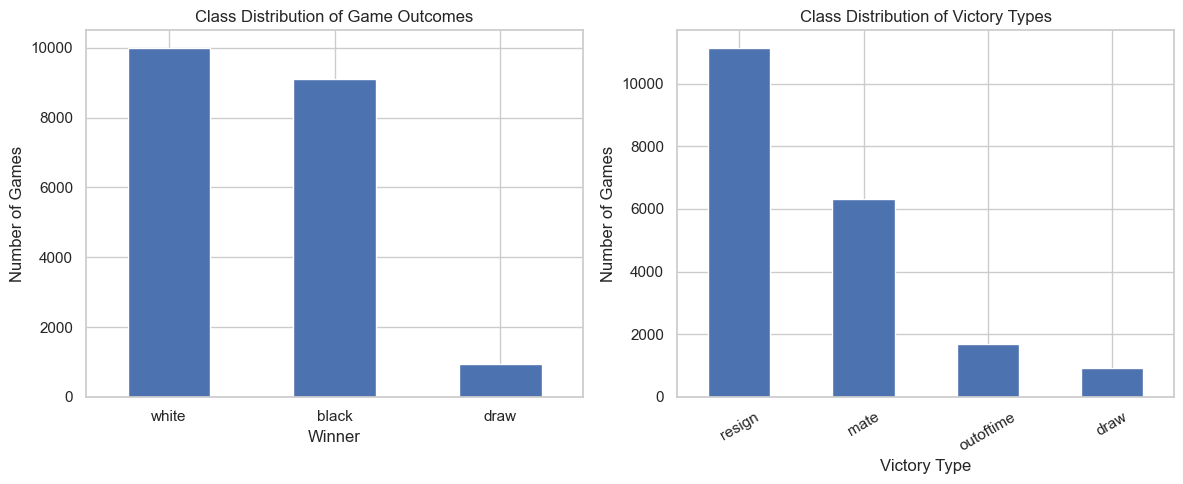

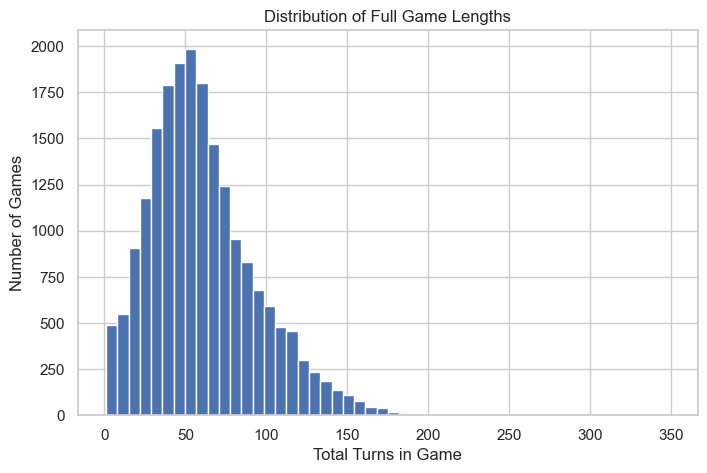

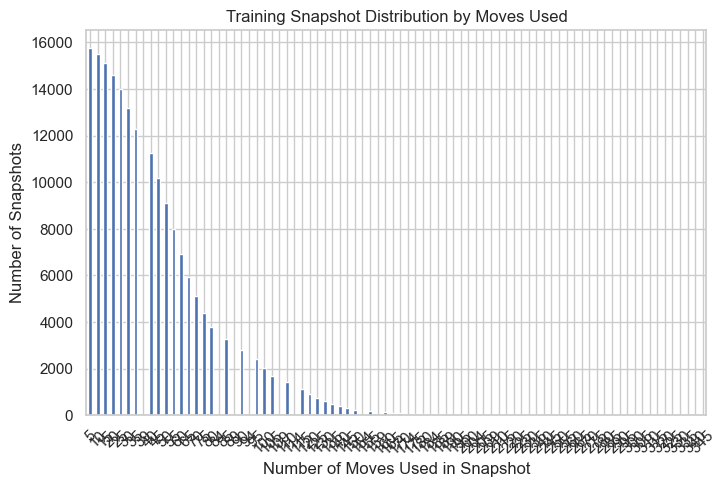

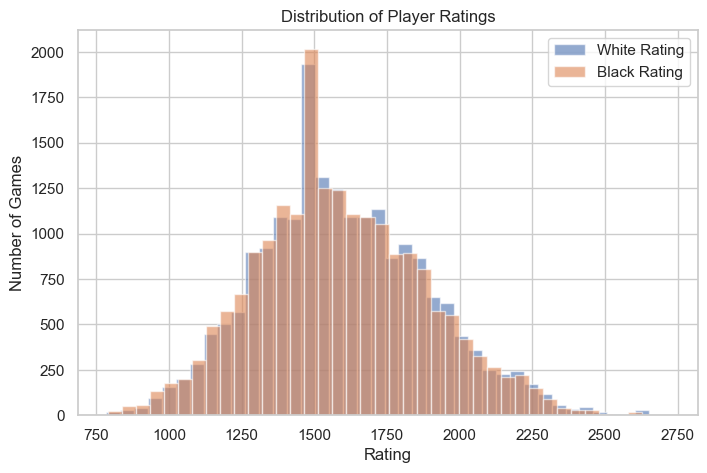

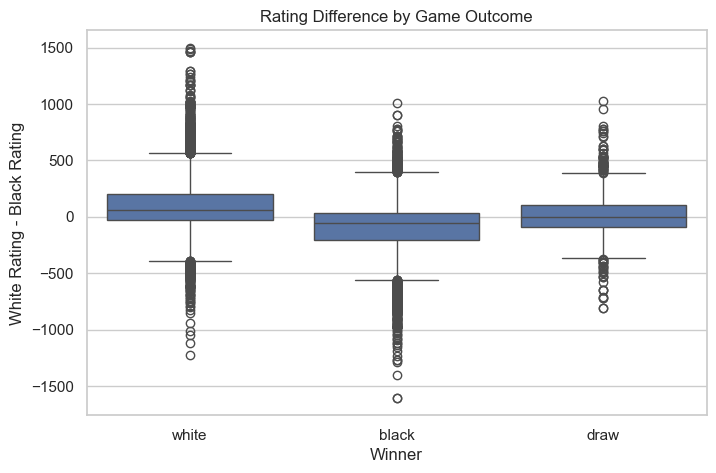

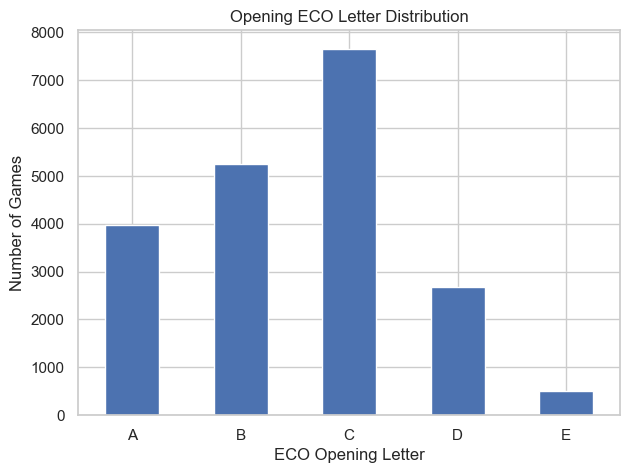

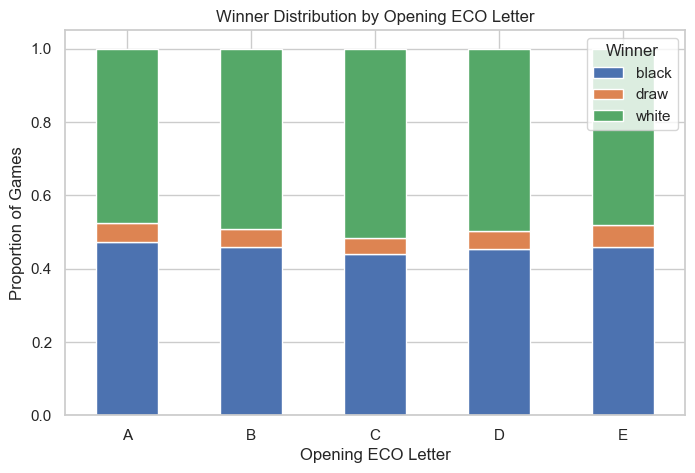

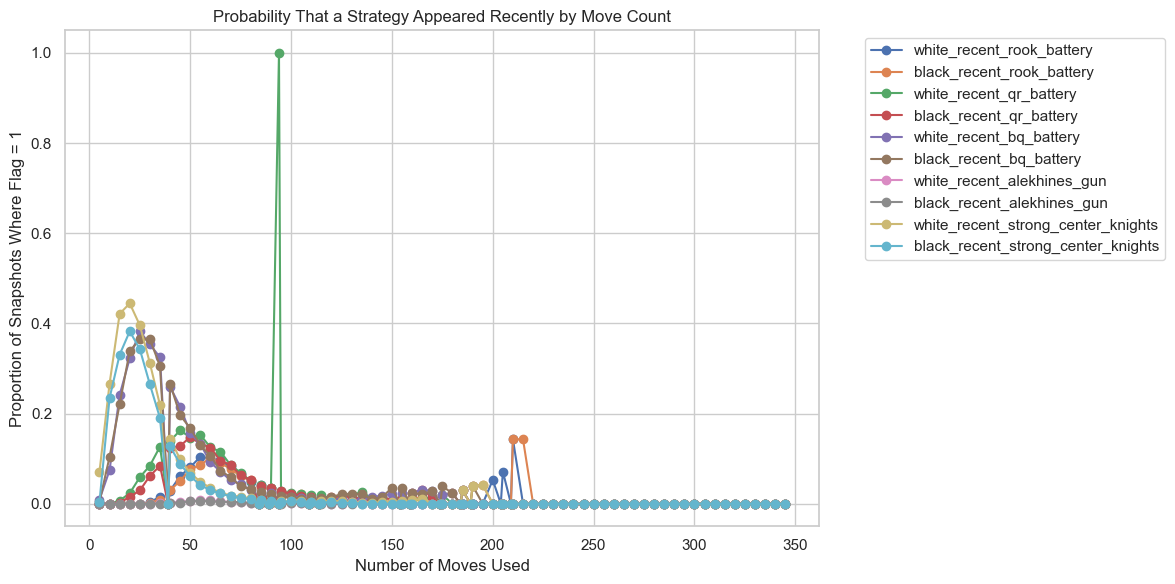

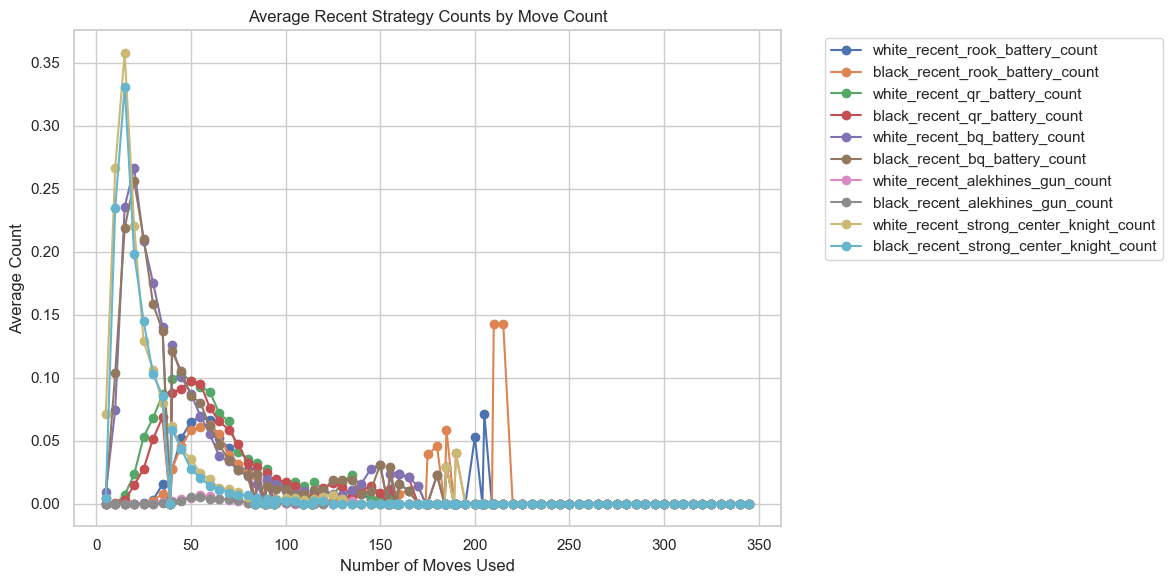

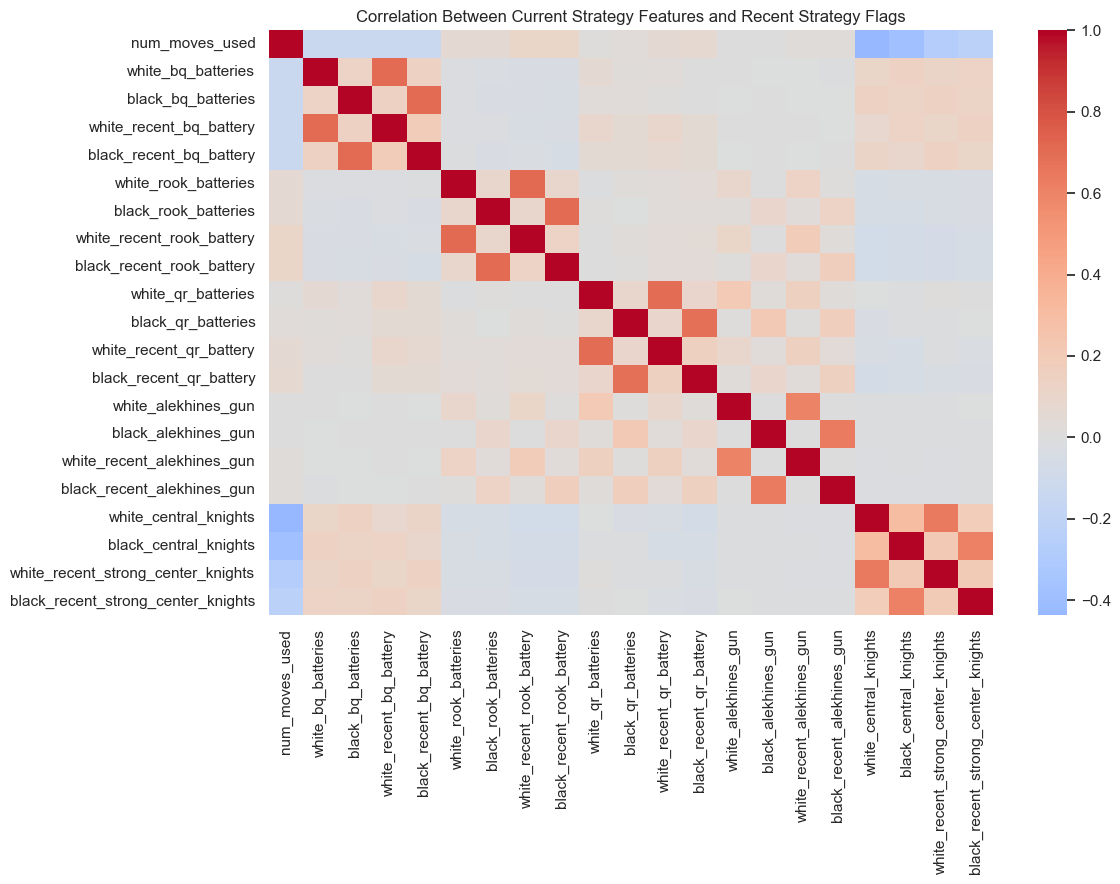


Strategy Features at 15 Moves


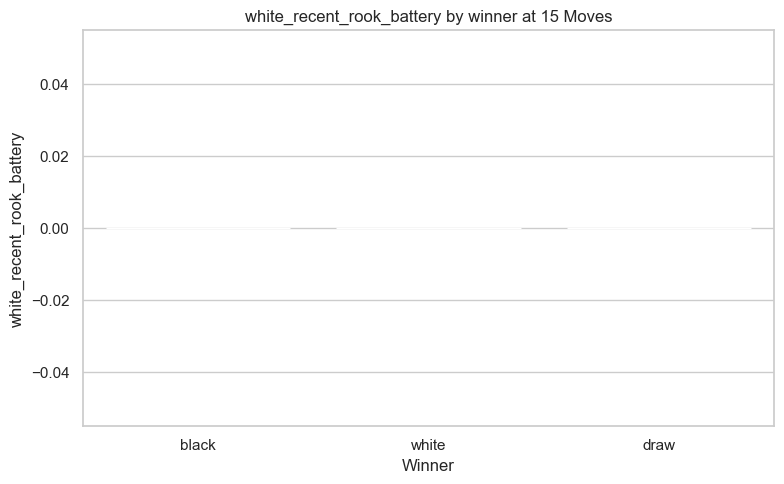

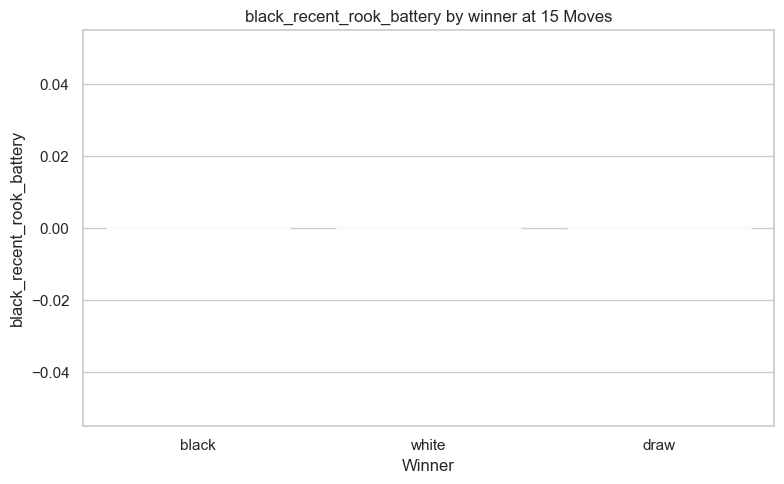

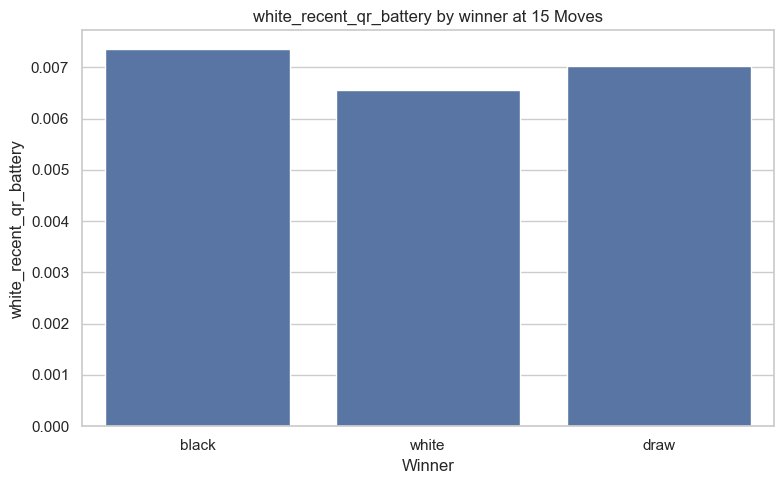

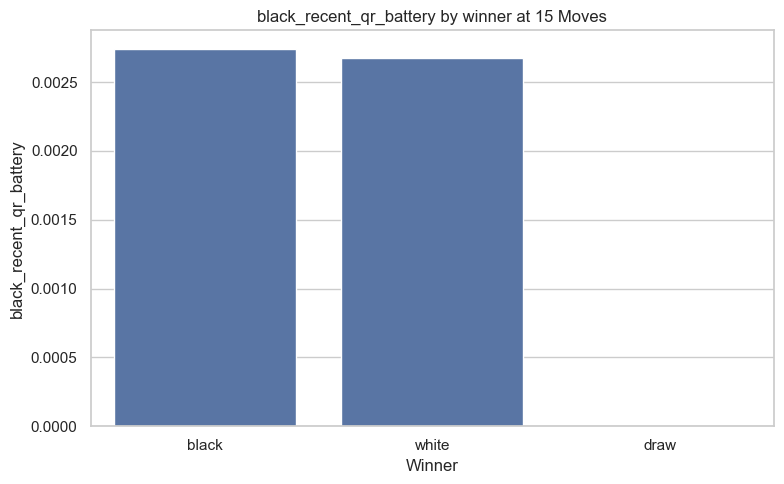

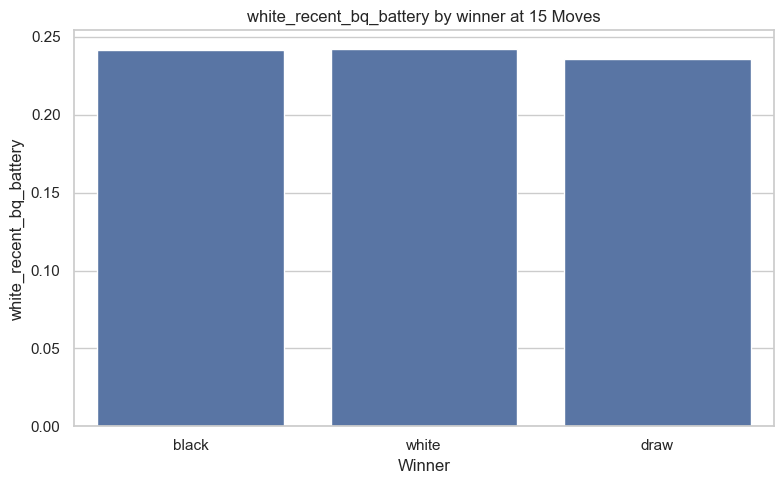

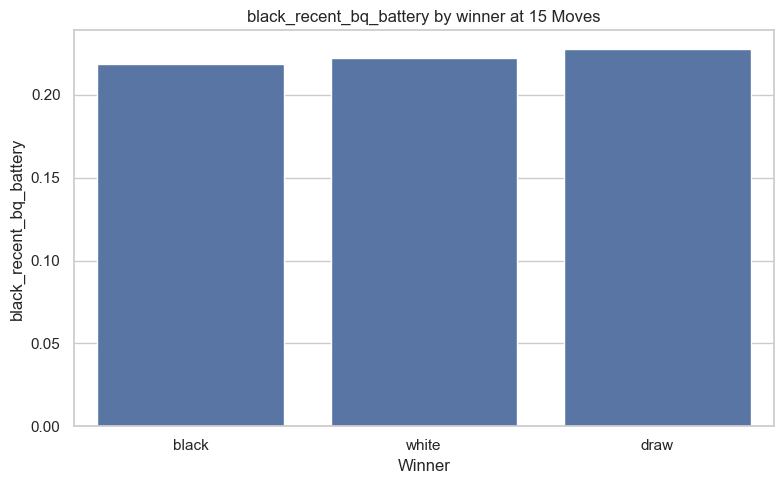

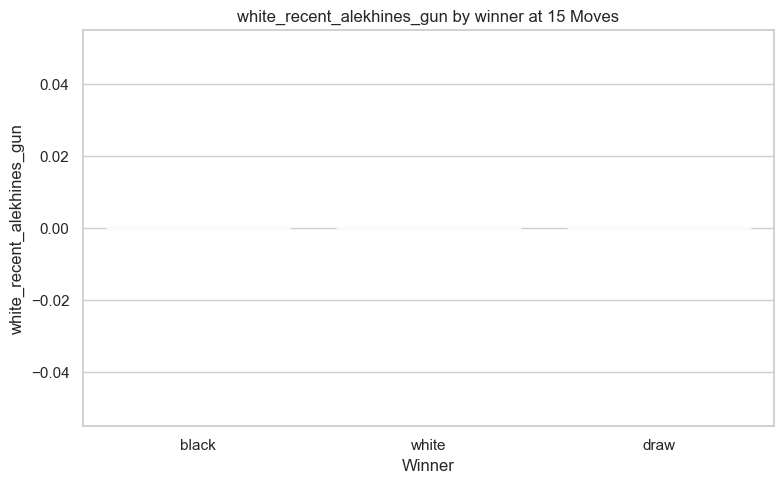

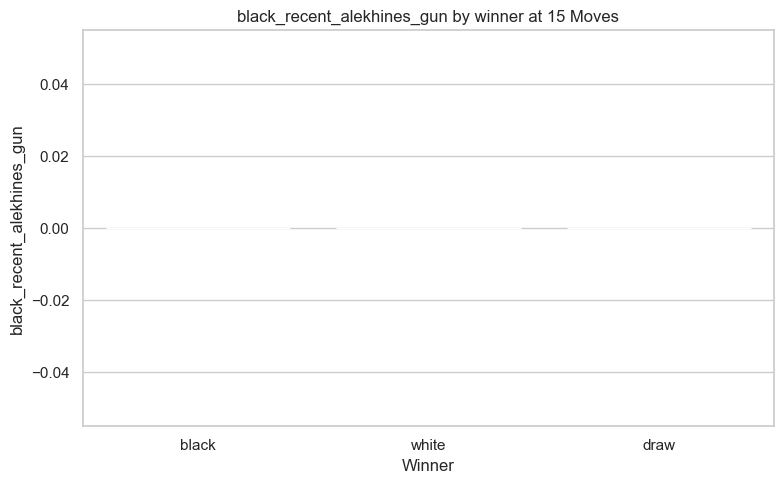

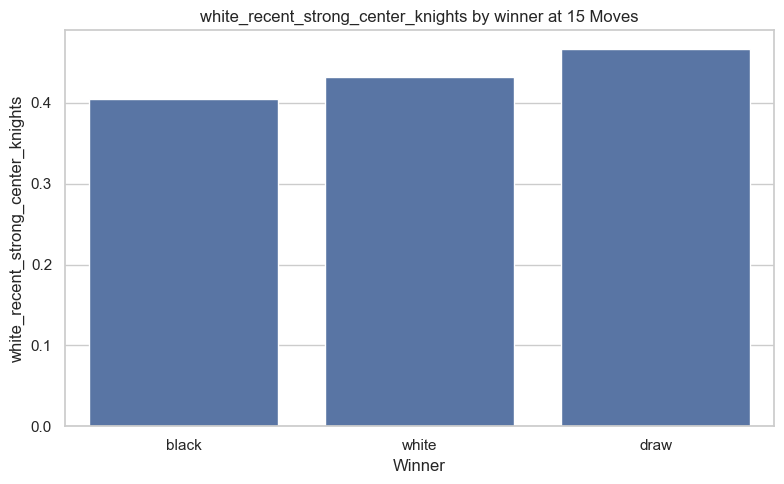

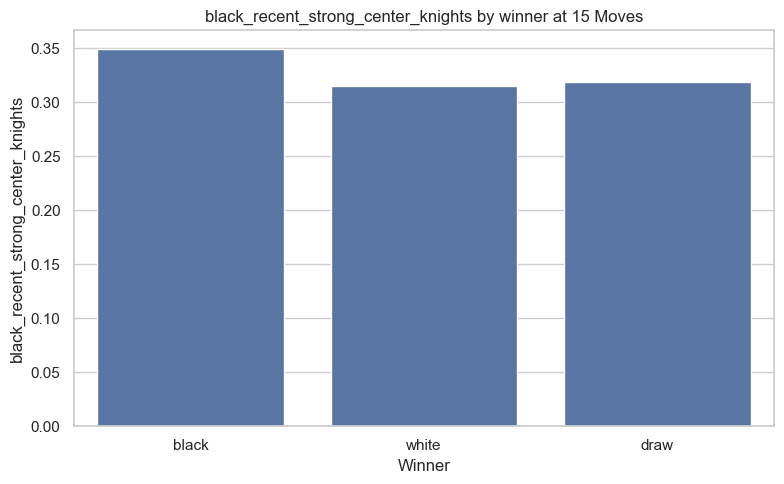


Strategy Features at 30 Moves


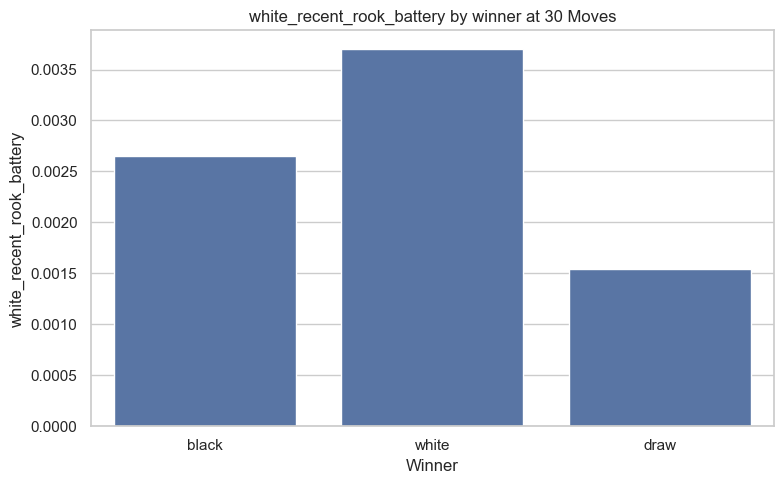

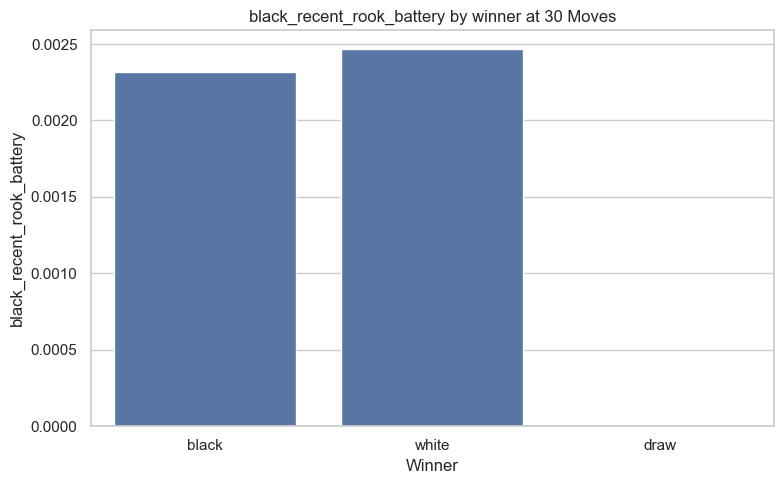

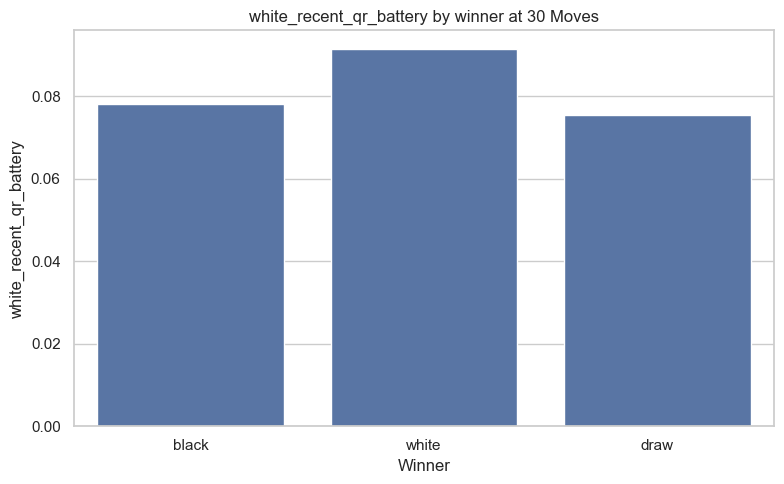

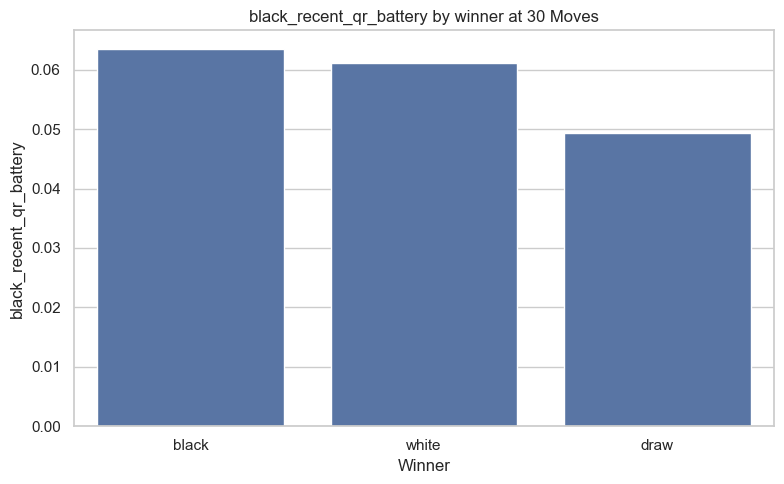

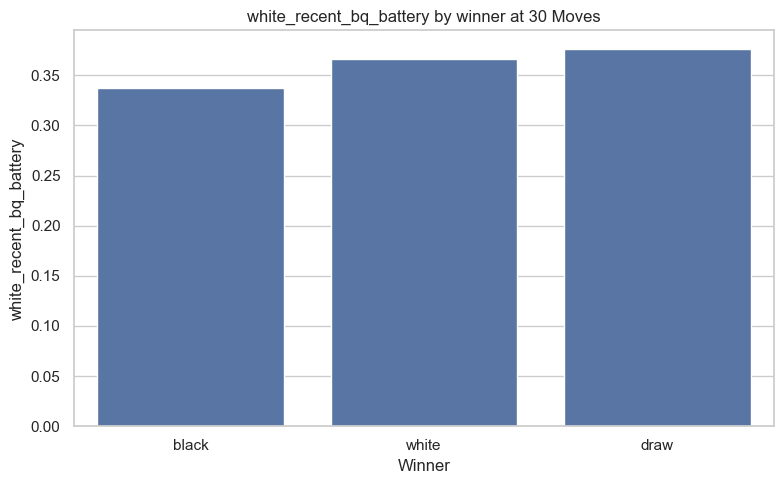

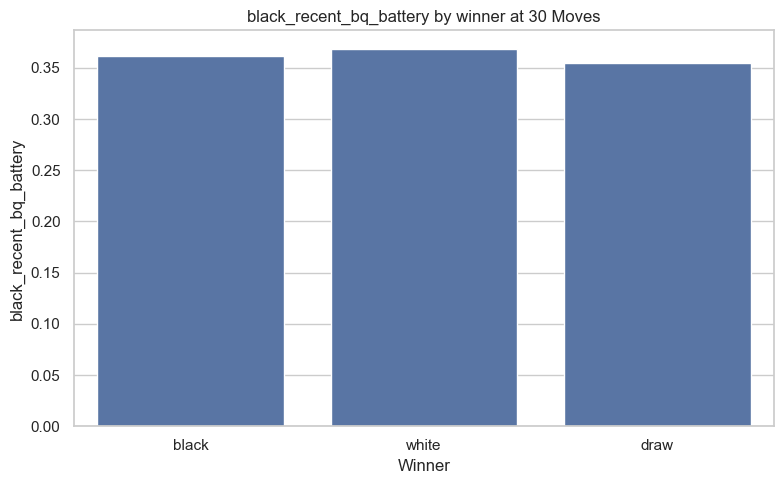

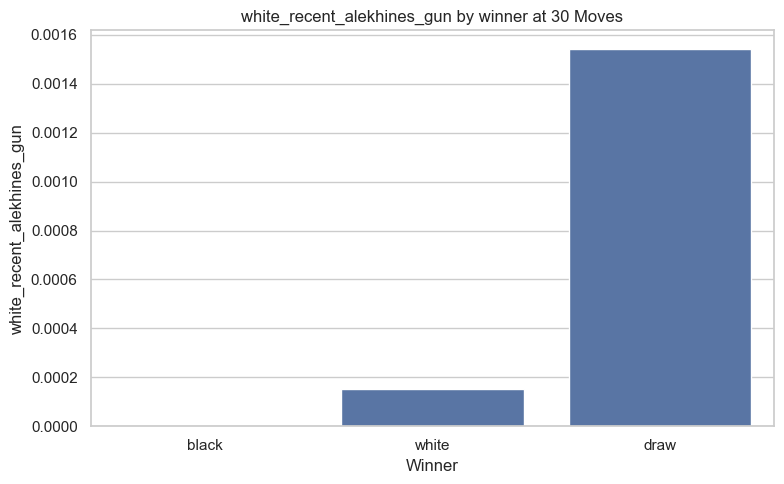

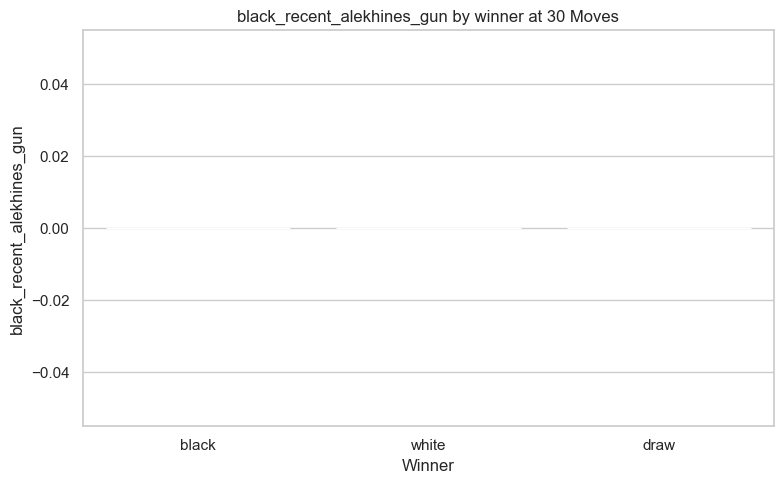

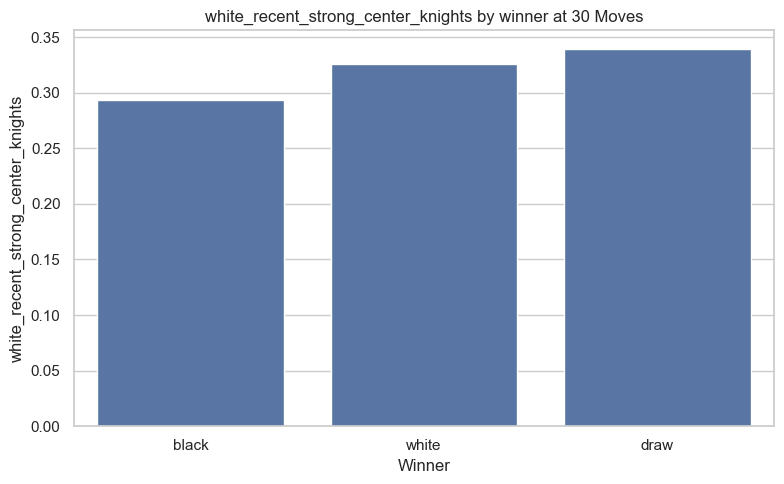

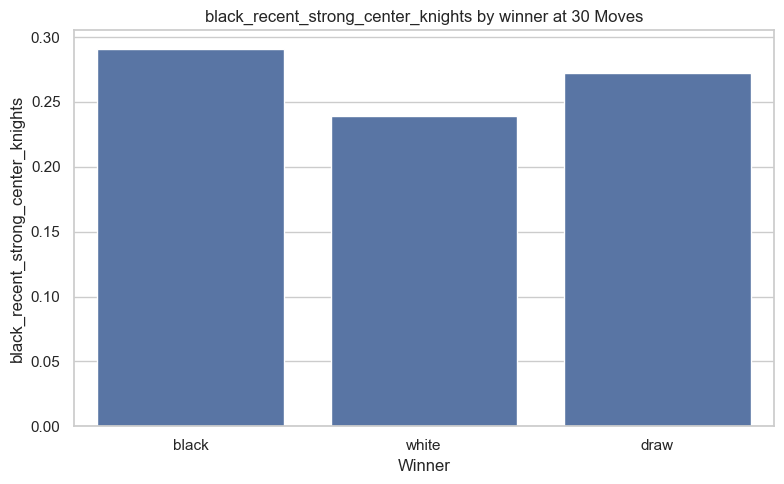


Strategy Features at 60 Moves


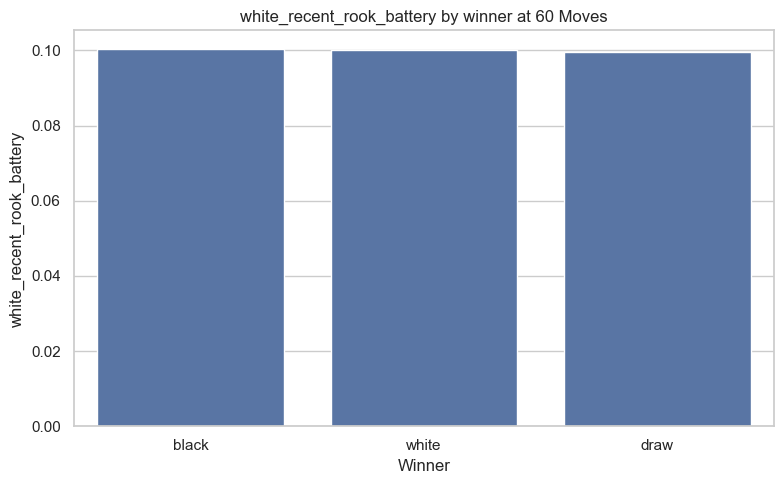

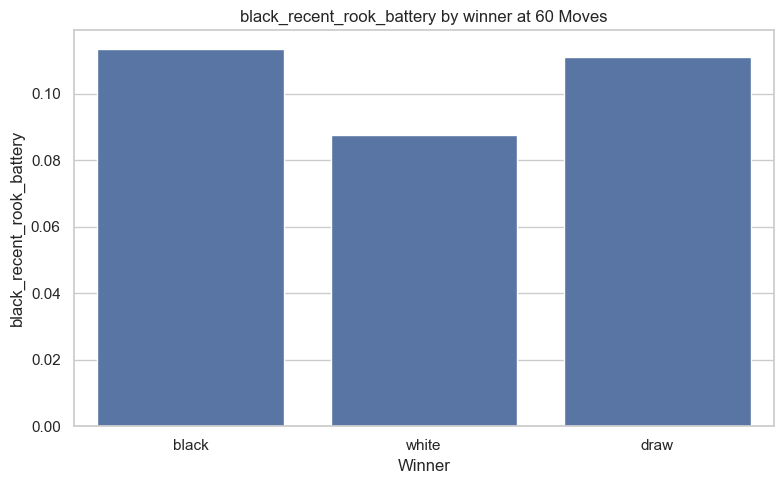

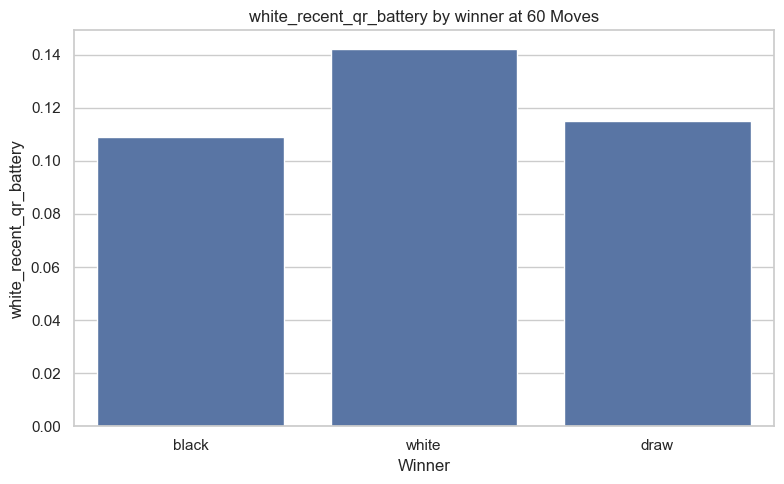

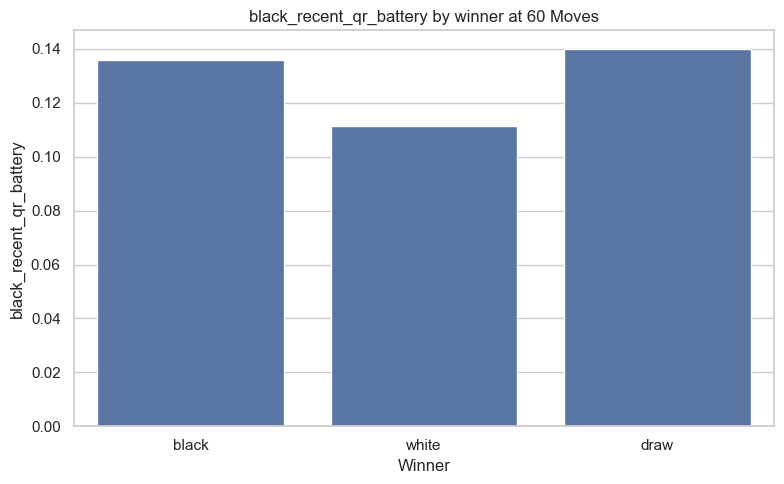

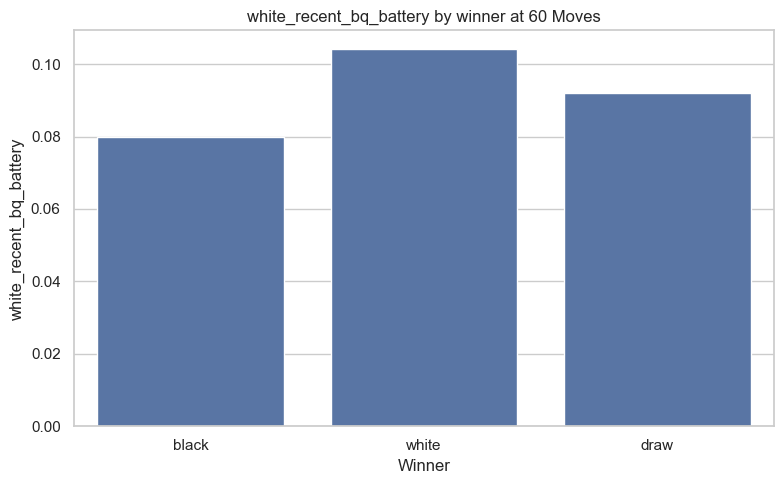

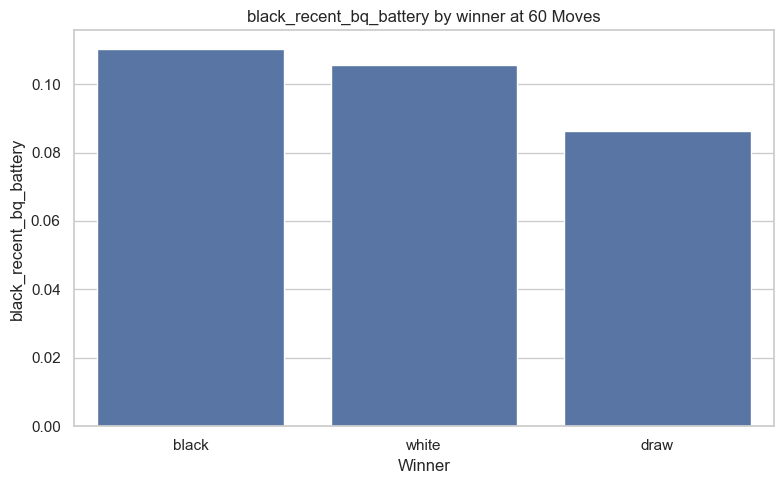

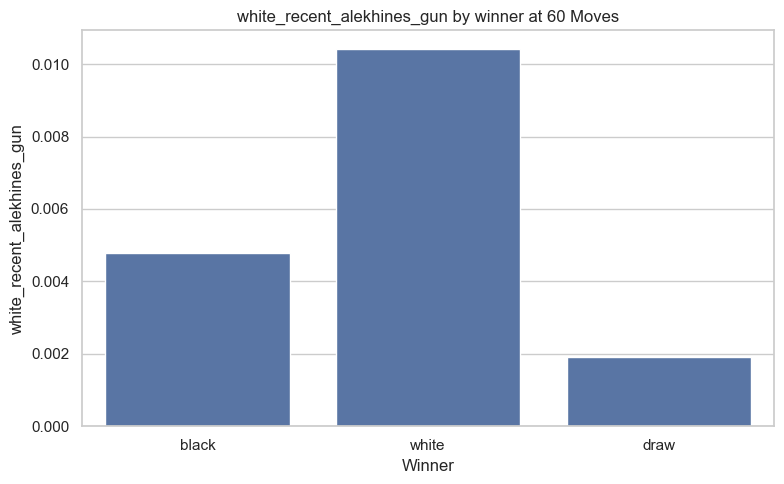

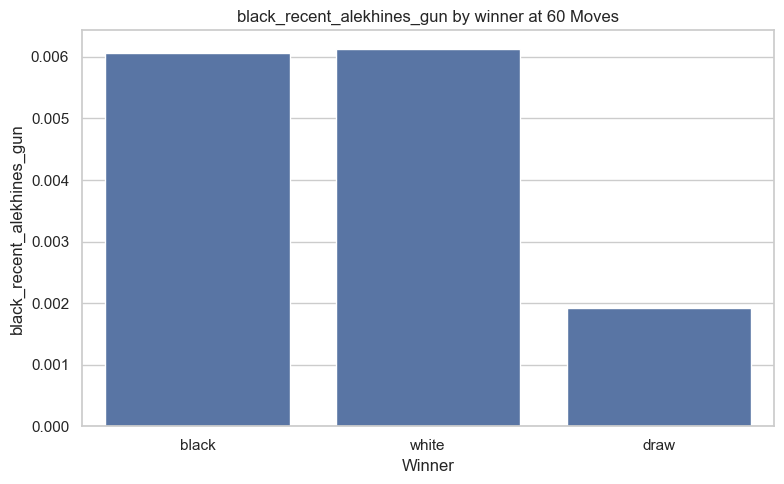

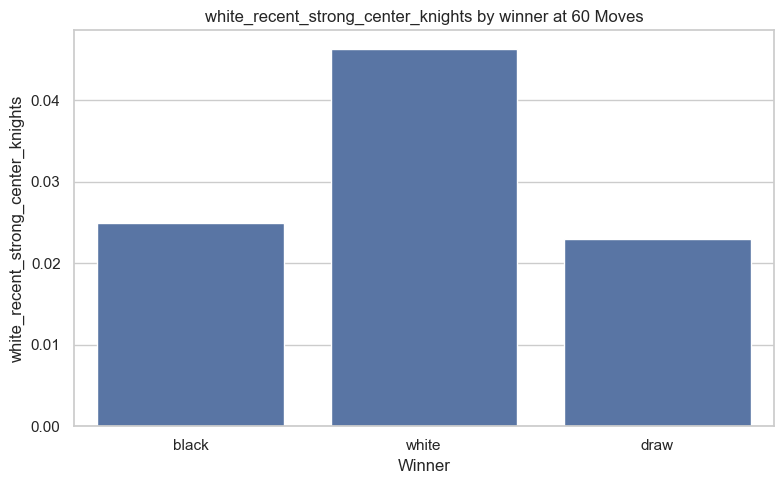

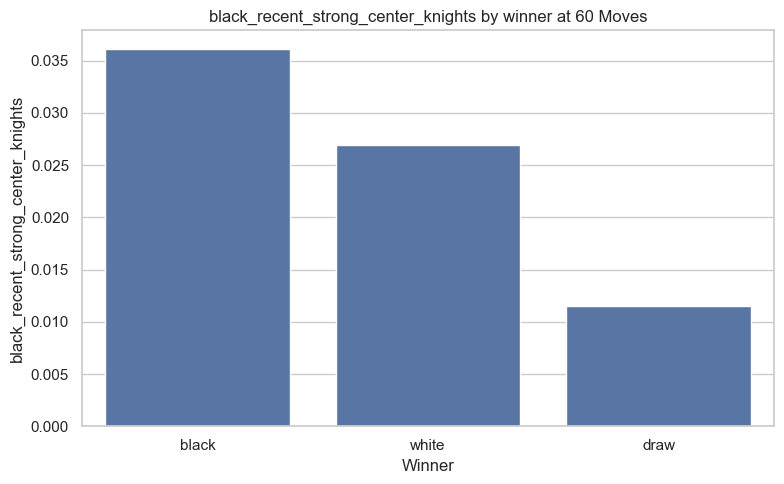

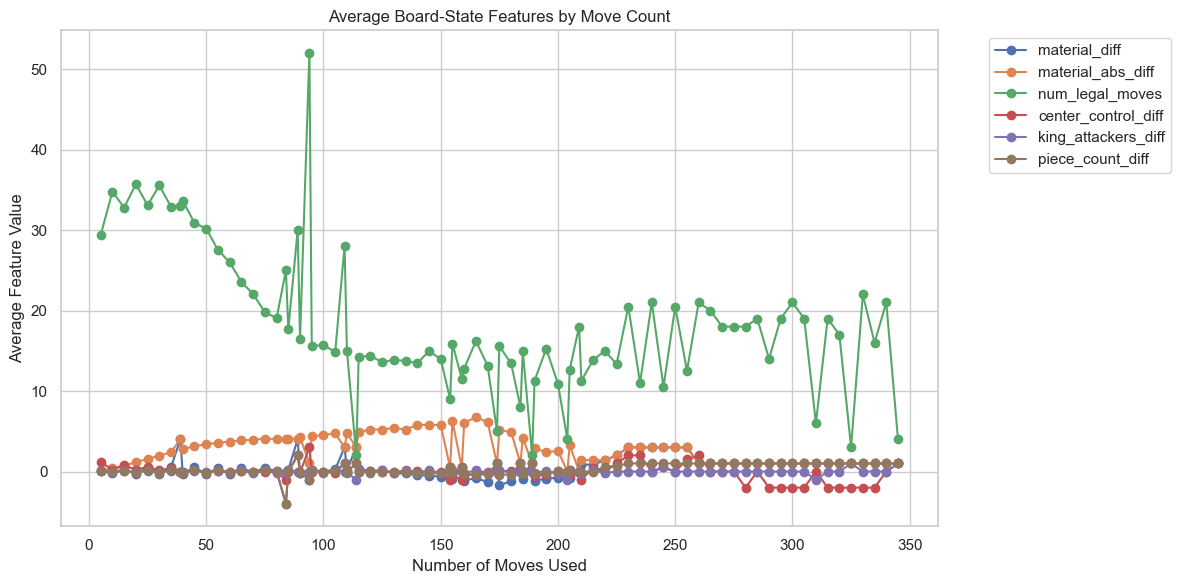

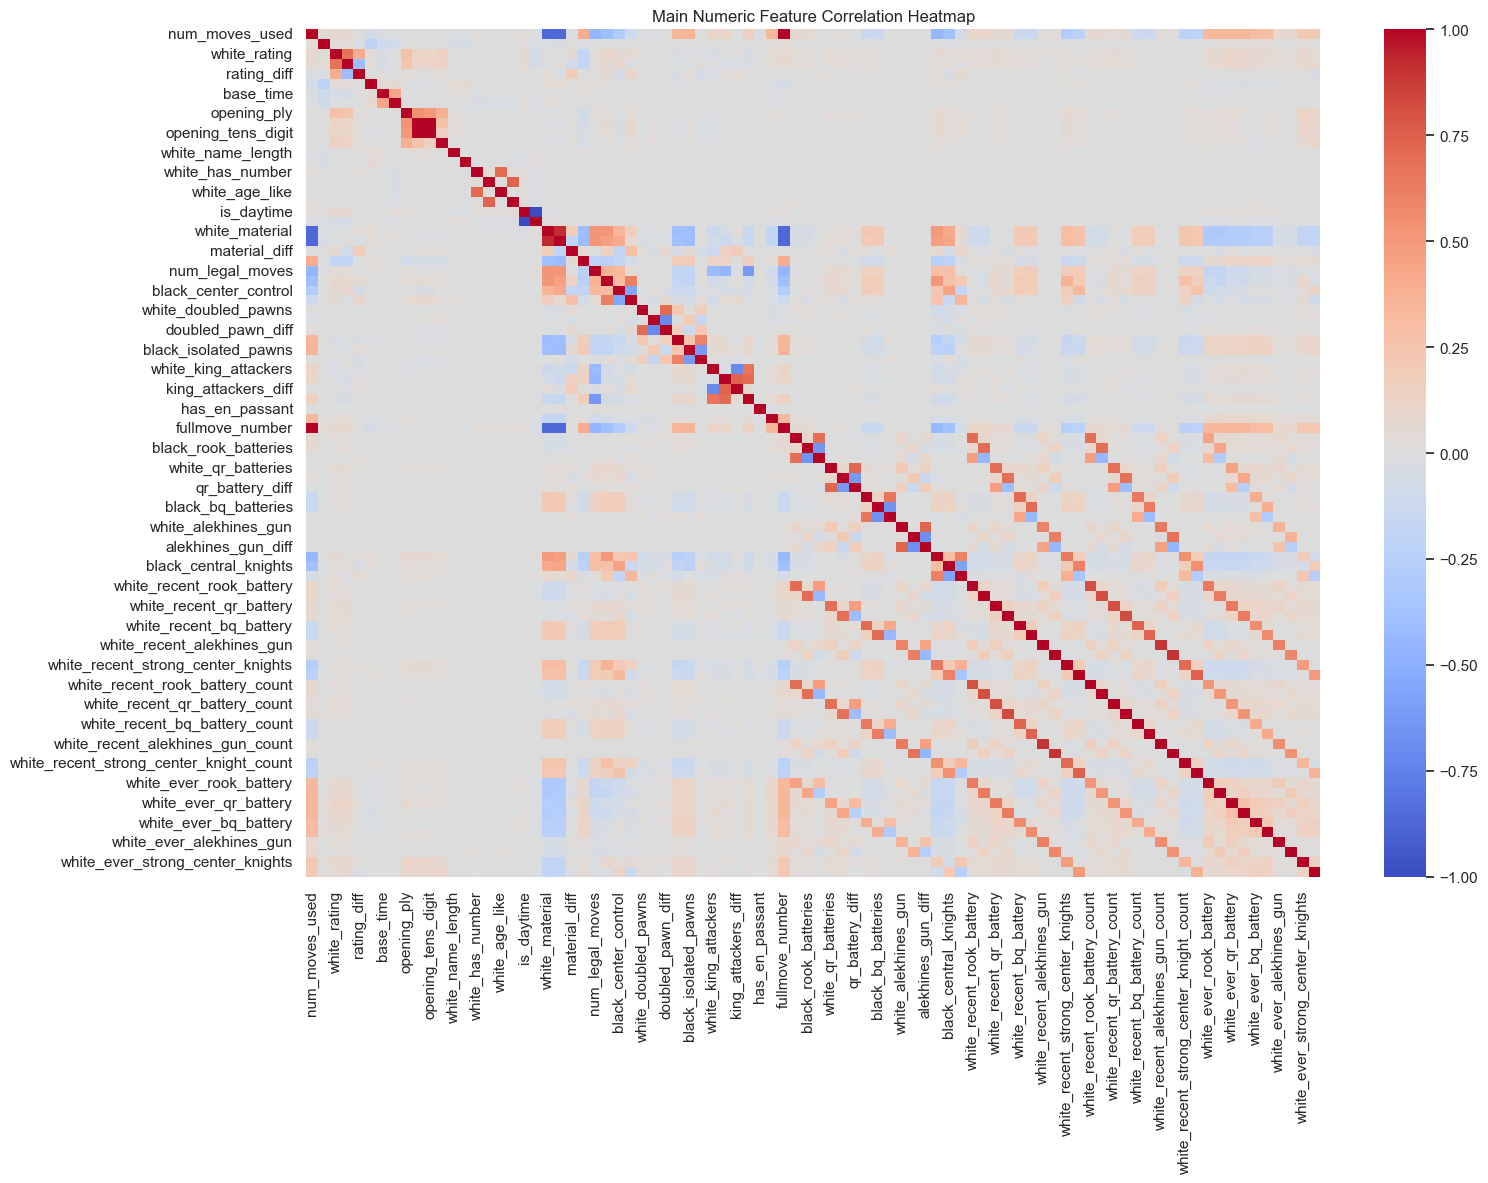

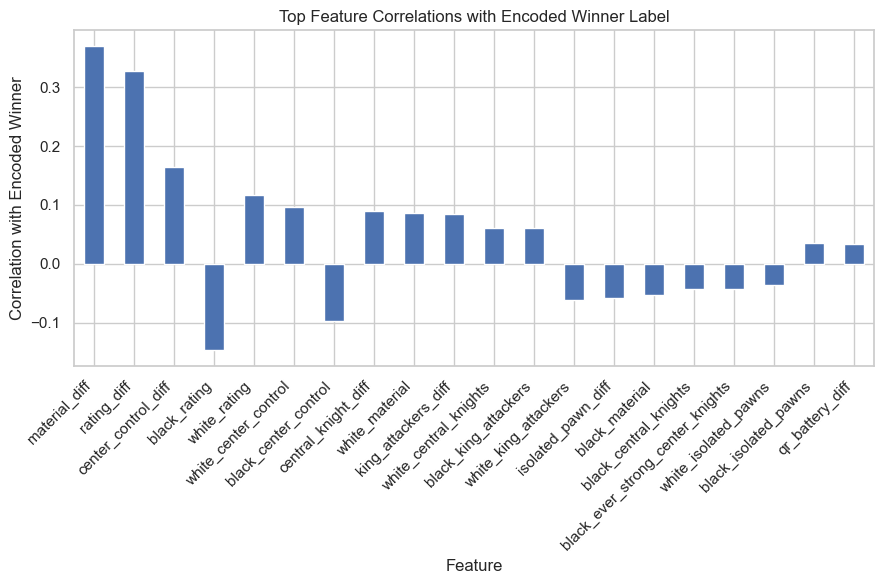

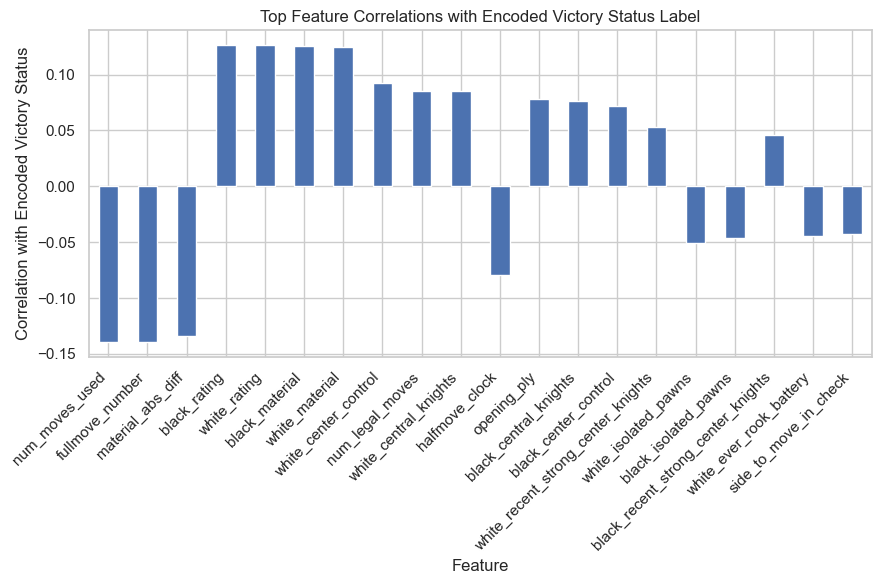

In [4]:
sns.set_theme(style="whitegrid")

# ============================================================
# Helper groups
# ============================================================

current_strategy_cols = [
    "white_rook_batteries",
    "black_rook_batteries",
    "rook_battery_diff",
    "white_qr_batteries",
    "black_qr_batteries",
    "qr_battery_diff",
    "white_bq_batteries",
    "black_bq_batteries",
    "bq_battery_diff",
    "white_alekhines_gun",
    "black_alekhines_gun",
    "alekhines_gun_diff",
    "white_central_knights",
    "black_central_knights",
    "central_knight_diff",
]

strategy_history_flag_cols = [
    "white_recent_rook_battery",
    "black_recent_rook_battery",
    "white_recent_qr_battery",
    "black_recent_qr_battery",
    "white_recent_bq_battery",
    "black_recent_bq_battery",
    "white_recent_alekhines_gun",
    "black_recent_alekhines_gun",
    "white_recent_strong_center_knights",
    "black_recent_strong_center_knights",
]

strategy_history_count_cols = [
    "white_recent_rook_battery_count",
    "black_recent_rook_battery_count",
    "white_recent_qr_battery_count",
    "black_recent_qr_battery_count",
    "white_recent_bq_battery_count",
    "black_recent_bq_battery_count",
    "white_recent_alekhines_gun_count",
    "black_recent_alekhines_gun_count",
    "white_recent_strong_center_knight_count",
    "black_recent_strong_center_knight_count",
]

strategy_ever_flag_cols = [
    "white_ever_rook_battery",
    "black_ever_rook_battery",
    "white_ever_qr_battery",
    "black_ever_qr_battery",
    "white_ever_bq_battery",
    "black_ever_bq_battery",
    "white_ever_alekhines_gun",
    "black_ever_alekhines_gun",
    "white_ever_strong_center_knights",
    "black_ever_strong_center_knights",
]

for col in strategy_ever_flag_cols:
    print(col, train_expanded[col].mean())

strategy_cols = [
    col for col in (
        current_strategy_cols +
        strategy_history_flag_cols +
        strategy_history_count_cols +
        strategy_ever_flag_cols
    )
    if col in train_expanded.columns
]


# ============================================================
# 1. Target class distributions
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

dataset["winner"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Class Distribution of Game Outcomes")
axes[0].set_xlabel("Winner")
axes[0].set_ylabel("Number of Games")
axes[0].tick_params(axis="x", rotation=0)

dataset["victory_status"].value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("Class Distribution of Victory Types")
axes[1].set_xlabel("Victory Type")
axes[1].set_ylabel("Number of Games")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


# ============================================================
# 2. Game length and snapshot distribution
# ============================================================

plt.figure(figsize=(8, 5))
plt.hist(dataset["turns"], bins=50)
plt.title("Distribution of Full Game Lengths")
plt.xlabel("Total Turns in Game")
plt.ylabel("Number of Games")
plt.show()

plt.figure(figsize=(8, 5))
train_expanded["num_moves_used"].value_counts().sort_index().plot(kind="bar")
plt.title("Training Snapshot Distribution by Moves Used")
plt.xlabel("Number of Moves Used in Snapshot")
plt.ylabel("Number of Snapshots")
plt.xticks(rotation=45)
plt.show()


# ============================================================
# 3. Ratings and opening features
# ============================================================

plt.figure(figsize=(8, 5))
plt.hist(dataset["white_rating"], bins=40, alpha=0.6, label="White Rating")
plt.hist(dataset["black_rating"], bins=40, alpha=0.6, label="Black Rating")
plt.title("Distribution of Player Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Games")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=dataset, x="winner", y="rating_diff")
plt.title("Rating Difference by Game Outcome")
plt.xlabel("Winner")
plt.ylabel("White Rating - Black Rating")
plt.show()

plt.figure(figsize=(7, 5))
dataset["opening_letter"].value_counts().sort_index().plot(kind="bar")
plt.title("Opening ECO Letter Distribution")
plt.xlabel("ECO Opening Letter")
plt.ylabel("Number of Games")
plt.xticks(rotation=0)
plt.show()

opening_winner_table = pd.crosstab(
    dataset["opening_letter"],
    dataset["winner"],
    normalize="index"
)

opening_winner_table.plot(kind="bar", stacked=True, figsize=(8, 5))
plt.title("Winner Distribution by Opening ECO Letter")
plt.xlabel("Opening ECO Letter")
plt.ylabel("Proportion of Games")
plt.xticks(rotation=0)
plt.legend(title="Winner")
plt.show()


# ============================================================
# 4. Strategy flags by number of moves used
# ============================================================

flag_means_by_move = train_expanded.groupby("num_moves_used")[strategy_history_flag_cols].mean()
flag_means_by_move = flag_means_by_move[
    [col for col in flag_means_by_move.columns if col in train_expanded.columns]
]

plt.figure(figsize=(12, 6))
for col in flag_means_by_move.columns:
    plt.plot(flag_means_by_move.index, flag_means_by_move[col], marker="o", label=col)

plt.title("Probability That a Strategy Appeared Recently by Move Count")
plt.xlabel("Number of Moves Used")
plt.ylabel("Proportion of Snapshots Where Flag = 1")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


# ============================================================
# 5. Strategy count features by number of moves used
# ============================================================

count_means_by_move = train_expanded.groupby("num_moves_used")[strategy_history_count_cols].mean()
count_means_by_move = count_means_by_move[
    [col for col in count_means_by_move.columns if col in train_expanded.columns]
]

plt.figure(figsize=(12, 6))
for col in count_means_by_move.columns:
    plt.plot(count_means_by_move.index, count_means_by_move[col], marker="o", label=col)

plt.title("Average Recent Strategy Counts by Move Count")
plt.xlabel("Number of Moves Used")
plt.ylabel("Average Count")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


# ============================================================
# 6. Current strategy features vs historical strategy flags
# ============================================================

strategy_relation_cols = [
    "num_moves_used",

    "white_bq_batteries",
    "black_bq_batteries",
    "white_recent_bq_battery",
    "black_recent_bq_battery",

    "white_rook_batteries",
    "black_rook_batteries",
    "white_recent_rook_battery",
    "black_recent_rook_battery",

    "white_qr_batteries",
    "black_qr_batteries",
    "white_recent_qr_battery",
    "black_recent_qr_battery",

    "white_alekhines_gun",
    "black_alekhines_gun",
    "white_recent_alekhines_gun",
    "black_recent_alekhines_gun",

    "white_central_knights",
    "black_central_knights",
    "white_recent_strong_center_knights",
    "black_recent_strong_center_knights",
]

strategy_relation_cols = [
    col for col in strategy_relation_cols
    if col in train_expanded.columns
]

strategy_corr = train_expanded[strategy_relation_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(strategy_corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Between Current Strategy Features and Recent Strategy Flags")
plt.tight_layout()
plt.show()


# ============================================================
# 7. Strategy features by winner
# ============================================================

def plot_strategic_plots(
    df,
    strategy_cols,
    move_points=[15, 30, 60],
    target_col="winner",
    plot_type="box"
):
    for move_value in move_points:
        window = 2
        move_df = df[
            (df["num_moves_used"] >= move_value - window) &
            (df["num_moves_used"] <= move_value + window)
        ].copy()

        if len(move_df) == 0:
            print(f"No snapshots found at {move_value} moves.")
            continue

        print("\n" + "=" * 70)
        print(f"Strategy Features at {move_value} Moves")
        print("=" * 70)

        for col in strategy_cols:
            if col not in move_df.columns:
                print(f"Skipping missing column: {col}")
                continue
                
            plt.figure(figsize=(8, 5))

            if plot_type == "box":
                sns.boxplot(data=move_df, x=target_col, y=col)

            elif plot_type == "bar":
                sns.barplot(data=move_df, x=target_col, y=col, errorbar=None)

            else:
                raise ValueError("plot_type must be 'box' or 'bar'")

            plt.title(f"{col} by {target_col} at {move_value} Moves")
            plt.xlabel(target_col.capitalize())
            plt.ylabel(col)
            plt.tight_layout()
            plt.show()


strategy_features_to_plot = [
    "white_recent_rook_battery",
    "black_recent_rook_battery",
    "white_recent_qr_battery",
    "black_recent_qr_battery",
    "white_recent_bq_battery",
    "black_recent_bq_battery",
    "white_recent_alekhines_gun",
    "black_recent_alekhines_gun",
    "white_recent_strong_center_knights",
    "black_recent_strong_center_knights",
]

plot_strategic_plots(
    df=train_expanded,
    strategy_cols=strategy_features_to_plot,
    move_points=[15, 30, 60],
    target_col="winner",
    plot_type="bar"
)

# ============================================================
# 9. Material, mobility, and board-state features by moves used
# ============================================================

board_progress_cols = [
    "material_diff",
    "material_abs_diff",
    "num_legal_moves",
    "center_control_diff",
    "king_attackers_diff",
    "piece_count_diff",
]

board_progress_cols = [
    col for col in board_progress_cols
    if col in train_expanded.columns
]

board_means_by_move = train_expanded.groupby("num_moves_used")[board_progress_cols].mean()

plt.figure(figsize=(12, 6))
for col in board_means_by_move.columns:
    plt.plot(board_means_by_move.index, board_means_by_move[col], marker="o", label=col)

plt.title("Average Board-State Features by Move Count")
plt.xlabel("Number of Moves Used")
plt.ylabel("Average Feature Value")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


# ============================================================
# 10. Full feature correlation heatmap
# ============================================================

plot_feature_cols = [
    col for col in feature_cols
    if col in train_expanded.columns
]

# Avoid massive heatmap if feature count is huge
main_corr_cols = [
    "num_moves_used",
    "rated",
    "white_rating",
    "black_rating",
    "rating_diff",
    "rating_abs_diff",
    "base_time",
    "time_increment",
    "opening_ply",
    "opening_number",
    "opening_tens_digit",
    "opening_ones_digit",
    "white_name_length",
    "black_name_length",
    "white_has_number",
    "black_has_number",
    "white_age_like",
    "black_age_like",
    "is_daytime",
    "is_night",
    "white_material",
    "black_material",
    "material_diff",
    "material_abs_diff",
    "num_legal_moves",
    "white_center_control",
    "black_center_control",
    "center_control_diff",
    "white_doubled_pawns",
    "black_doubled_pawns",
    "doubled_pawn_diff",
    "white_isolated_pawns",
    "black_isolated_pawns",
    "isolated_pawn_diff",
    "white_king_attackers",
    "black_king_attackers",
    "king_attackers_diff",
    "side_to_move_in_check",
    "has_en_passant",
    "halfmove_clock",
    "fullmove_number",
] + strategy_cols

main_corr_cols = [
    col for col in main_corr_cols
    if col in train_expanded.columns
]

corr_matrix = train_expanded[main_corr_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Main Numeric Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


# ============================================================
# 11. Top correlations with encoded labels
# ============================================================

corr_with_winner = train_expanded[main_corr_cols + ["y_winner"]].corr()["y_winner"]
corr_with_winner = corr_with_winner.drop("y_winner").sort_values(key=abs, ascending=False)

plt.figure(figsize=(9, 6))
corr_with_winner.head(20).plot(kind="bar")
plt.title("Top Feature Correlations with Encoded Winner Label")
plt.xlabel("Feature")
plt.ylabel("Correlation with Encoded Winner")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

corr_with_status = train_expanded[main_corr_cols + ["y_status"]].corr()["y_status"]
corr_with_status = corr_with_status.drop("y_status").sort_values(key=abs, ascending=False)

plt.figure(figsize=(9, 6))
corr_with_status.head(20).plot(kind="bar")
plt.title("Top Feature Correlations with Encoded Victory Status Label")
plt.xlabel("Feature")
plt.ylabel("Correlation with Encoded Victory Status")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [5]:
x_train = X_train_global
x_test = X_test_global

y_train_winner = y_winner_train
y_test_winner = y_winner_test

y_train_status = y_status_train
y_test_status = y_status_test

y_train_multi = train_expanded[["winner", "victory_status"]]
y_test_multi = test_expanded[["winner", "victory_status"]]

groups = train_expanded["id"]

print("Random Forest training shape:", x_train.shape)
print("Random Forest testing shape:", x_test.shape)


param_distributions = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [None, 10, 20, 30, 40],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

group_cv = GroupKFold(n_splits=5)
candidate_feature_counts = [10, 15, 20, 25, 30, 40, 50, 75, 100, 125]


def get_feature_importance_ranking(x_train, y_train, feature_cols):
    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    rf.fit(x_train, y_train)

    importance_df = pd.DataFrame({
        "feature": feature_cols,
        "importance": rf.feature_importances_
    }).sort_values("importance", ascending=False)

    return importance_df


def find_best_feature_set_single_output(
    x_train,
    y_train,
    feature_cols,
    groups,
    model_name,
    candidate_feature_counts
):
    print("\n" + "=" * 70)
    print(f"Finding best feature set for {model_name}")
    print("=" * 70)

    importance_df = get_feature_importance_ranking(
        x_train,
        y_train,
        feature_cols
    )

    results = []

    for k in candidate_feature_counts:
        k = min(k, len(feature_cols))
        selected_features = importance_df.head(k)["feature"].tolist()

        rf = RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            max_features="sqrt",
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )

        scores = cross_val_score(
            rf,
            x_train[selected_features],
            y_train,
            cv=group_cv,
            groups=groups,
            scoring="f1_weighted",
            n_jobs=-1
        )

        results.append({
            "num_features": k,
            "mean_f1": scores.mean(),
            "std_f1": scores.std(),
            "features": selected_features
        })

        print(f"Top {k:3d} features | F1 = {scores.mean():.4f} ± {scores.std():.4f}")

    results_df = pd.DataFrame(results)
    best_row = results_df.sort_values("mean_f1", ascending=False).iloc[0]

    best_features = best_row["features"]

    print("\nBest number of features:", best_row["num_features"])
    print("Best CV F1:", best_row["mean_f1"])

    return best_features, importance_df, results_df


def multioutput_f1_score(y_true, y_pred):
    y_true = np.asarray(y_true)

    winner_f1 = f1_score(
        y_true[:, 0],
        y_pred[:, 0],
        average="weighted",
        zero_division=0
    )

    status_f1 = f1_score(
        y_true[:, 1],
        y_pred[:, 1],
        average="weighted",
        zero_division=0
    )

    return (winner_f1 + status_f1) / 2


multioutput_scorer = make_scorer(multioutput_f1_score)


def find_best_feature_set_multi_output(
    x_train,
    y_train_multi,
    feature_cols,
    groups,
    model_name,
    candidate_feature_counts
):
    print("\n" + "=" * 70)
    print(f"Finding best feature set for {model_name}")
    print("=" * 70)

    # Rank features using winner + status importances averaged
    winner_importance = get_feature_importance_ranking(
        x_train,
        y_train_multi["winner"],
        feature_cols
    )

    status_importance = get_feature_importance_ranking(
        x_train,
        y_train_multi["victory_status"],
        feature_cols
    )

    merged_importance = winner_importance.merge(
        status_importance,
        on="feature",
        suffixes=("_winner", "_status")
    )

    merged_importance["importance"] = (
        merged_importance["importance_winner"] +
        merged_importance["importance_status"]
    ) / 2

    importance_df = merged_importance.sort_values("importance", ascending=False)

    results = []

    for k in candidate_feature_counts:
        k = min(k, len(feature_cols))
        selected_features = importance_df.head(k)["feature"].tolist()

        base_rf = RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            max_features="sqrt",
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )

        multi_rf = MultiOutputClassifier(base_rf, n_jobs=-1)

        scores = cross_val_score(
            multi_rf,
            x_train[selected_features],
            y_train_multi,
            cv=group_cv,
            groups=groups,
            scoring=multioutput_scorer,
            n_jobs=-1
        )

        results.append({
            "num_features": k,
            "mean_f1": scores.mean(),
            "std_f1": scores.std(),
            "features": selected_features
        })

        print(f"Top {k:3d} features | Avg Multi-Output F1 = {scores.mean():.4f} ± {scores.std():.4f}")

    results_df = pd.DataFrame(results)
    best_row = results_df.sort_values("mean_f1", ascending=False).iloc[0]

    best_features = best_row["features"]

    print("\nBest number of features:", best_row["num_features"])
    print("Best CV Avg F1:", best_row["mean_f1"])

    return best_features, importance_df, results_df


Random Forest training shape: (184180, 129)
Random Forest testing shape: (46350, 129)


In [6]:
winner_best_features, winner_importance_df, winner_feature_results = \
    find_best_feature_set_single_output(
        x_train=x_train,
        y_train=y_train_winner,
        feature_cols=feature_cols,
        groups=groups,
        model_name="Winner RF",
        candidate_feature_counts=candidate_feature_counts
    )

status_best_features, status_importance_df, status_feature_results = \
    find_best_feature_set_single_output(
        x_train=x_train,
        y_train=y_train_status,
        feature_cols=feature_cols,
        groups=groups,
        model_name="Victory Status RF",
        candidate_feature_counts=candidate_feature_counts
    )

multi_best_features, multi_importance_df, multi_feature_results = \
    find_best_feature_set_multi_output(
        x_train=x_train,
        y_train_multi=y_train_multi,
        feature_cols=feature_cols,
        groups=groups,
        model_name="Multi-Output RF",
        candidate_feature_counts=candidate_feature_counts
    )


Finding best feature set for Winner RF
Top  10 features | F1 = 0.6073 ± 0.0067
Top  15 features | F1 = 0.6305 ± 0.0058
Top  20 features | F1 = 0.6335 ± 0.0049
Top  25 features | F1 = 0.6346 ± 0.0051
Top  30 features | F1 = 0.6370 ± 0.0049
Top  40 features | F1 = 0.6393 ± 0.0048
Top  50 features | F1 = 0.6403 ± 0.0044
Top  75 features | F1 = 0.6410 ± 0.0044
Top 100 features | F1 = 0.6421 ± 0.0047
Top 125 features | F1 = 0.6422 ± 0.0040

Best number of features: 125
Best CV F1: 0.6421945917931303

Finding best feature set for Victory Status RF
Top  10 features | F1 = 0.4385 ± 0.0093
Top  15 features | F1 = 0.4667 ± 0.0098
Top  20 features | F1 = 0.4703 ± 0.0078
Top  25 features | F1 = 0.4728 ± 0.0096
Top  30 features | F1 = 0.4742 ± 0.0078
Top  40 features | F1 = 0.4717 ± 0.0096
Top  50 features | F1 = 0.4682 ± 0.0078
Top  75 features | F1 = 0.4673 ± 0.0102
Top 100 features | F1 = 0.4646 ± 0.0090
Top 125 features | F1 = 0.4647 ± 0.0093

Best number of features: 30
Best CV F1: 0.47418191

In [7]:
rf_winner_base = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_status_base = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

multi_rf_base = MultiOutputClassifier(
    RandomForestClassifier(
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),
    n_jobs=-1
)

winner_search = RandomizedSearchCV(
    estimator=rf_winner_base,
    param_distributions=param_distributions,
    n_iter=15,
    cv=group_cv,
    scoring="f1_weighted",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

status_search = RandomizedSearchCV(
    estimator=rf_status_base,
    param_distributions=param_distributions,
    n_iter=15,
    cv=group_cv,
    scoring="f1_weighted",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

multi_param_distributions = {
    "estimator__n_estimators": [100, 200, 300, 400],
    "estimator__max_depth": [None, 10, 20, 30, 40],
    "estimator__min_samples_split": [2, 5, 10],
    "estimator__min_samples_leaf": [1, 2, 4],
    "estimator__max_features": ["sqrt", "log2", None]
}

multi_search = RandomizedSearchCV(
    estimator=multi_rf_base,
    param_distributions=multi_param_distributions,
    n_iter=15,
    cv=group_cv,
    scoring=multioutput_scorer,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Optimizing winner model...")
winner_search.fit(x_train[winner_best_features], y_train_winner, groups=groups)

print("\nOptimizing victory status model...")
status_search.fit(x_train[status_best_features], y_train_status, groups=groups)

print("\nOptimizing multi-output model...")
multi_search.fit(x_train[multi_best_features], y_train_multi, groups=groups)

rf_winner_best = winner_search.best_estimator_
rf_status_best = status_search.best_estimator_
rf_multi_best = multi_search.best_estimator_

print("\nBest winner parameters:")
print(winner_search.best_params_)
print("Best winner CV weighted F1:", winner_search.best_score_)

print("\nBest status parameters:")
print(status_search.best_params_)
print("Best status CV weighted F1:", status_search.best_score_)

print("\nBest multi-output parameters:")
print(multi_search.best_params_)
print("Best multi-output CV average F1:", multi_search.best_score_)

Optimizing winner model...
Fitting 5 folds for each of 15 candidates, totalling 75 fits

Optimizing victory status model...
Fitting 5 folds for each of 15 candidates, totalling 75 fits

Optimizing multi-output model...
Fitting 5 folds for each of 15 candidates, totalling 75 fits

Best winner parameters:
{'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 20}
Best winner CV weighted F1: 0.6503546636791445

Best status parameters:
{'n_estimators': 400, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 30}
Best status CV weighted F1: 0.4960877575914376

Best multi-output parameters:
{'estimator__n_estimators': 100, 'estimator__min_samples_split': 10, 'estimator__min_samples_leaf': 2, 'estimator__max_features': 'log2', 'estimator__max_depth': 20}
Best multi-output CV average F1: 0.5723356581138491



Random Forest Validation around 10 moves (+/- 3)
Number of snapshots: 3872

--- Winner RF ---
Accuracy: 0.6299070247933884
Precision weighted: 0.6367217127061098
Recall weighted: 0.6299070247933884
F1 weighted: 0.6204779470927841

--- Status RF ---
Accuracy: 0.5730888429752066
Precision weighted: 0.5703607632733924
Recall weighted: 0.5730888429752066
F1 weighted: 0.5326911419136987

--- Multi-Output RF Winner ---
Accuracy: 0.6348140495867769
Precision weighted: 0.6340912366773388
Recall weighted: 0.6348140495867769
F1 weighted: 0.6264904507353876

--- Multi-Output RF Status ---
Accuracy: 0.5643078512396694
Precision weighted: 0.5510023019329704
Recall weighted: 0.5643078512396694
F1 weighted: 0.5375821701345502

Random Forest Validation around 25 moves (+/- 3)
Number of snapshots: 3490

--- Winner RF ---
Accuracy: 0.6512893982808023
Precision weighted: 0.667259706933959
Recall weighted: 0.6512893982808023
F1 weighted: 0.6399807409329009

--- Status RF ---
Accuracy: 0.5727793696275072


,model,target,num_moves_used,f1,recall,precision,accuracy
0,Winner RF,winner,10,0.620478,0.629907,0.636722,0.629907
1,Status RF,status,10,0.532691,0.573089,0.570361,0.573089
2,Multi-Output RF Winner,winner,10,0.626490,0.634814,0.634091,0.634814
3,Multi-Output RF Status,status,10,0.537582,0.564308,0.551002,0.564308
4,Winner RF,winner,25,0.639981,0.651289,0.667260,0.651289
5,Status RF,status,25,0.533032,0.572779,0.592523,0.572779
6,Multi-Output RF Winner,winner,25,0.640561,0.651289,0.657529,0.651289
7,Multi-Output RF Status,status,25,0.534172,0.563037,0.560958,0.563037
8,Winner RF,winner,40,0.680188,0.693062,0.704399,0.693062
9,Status RF,status,40,0.535557,0.571128,0.597235,0.571128


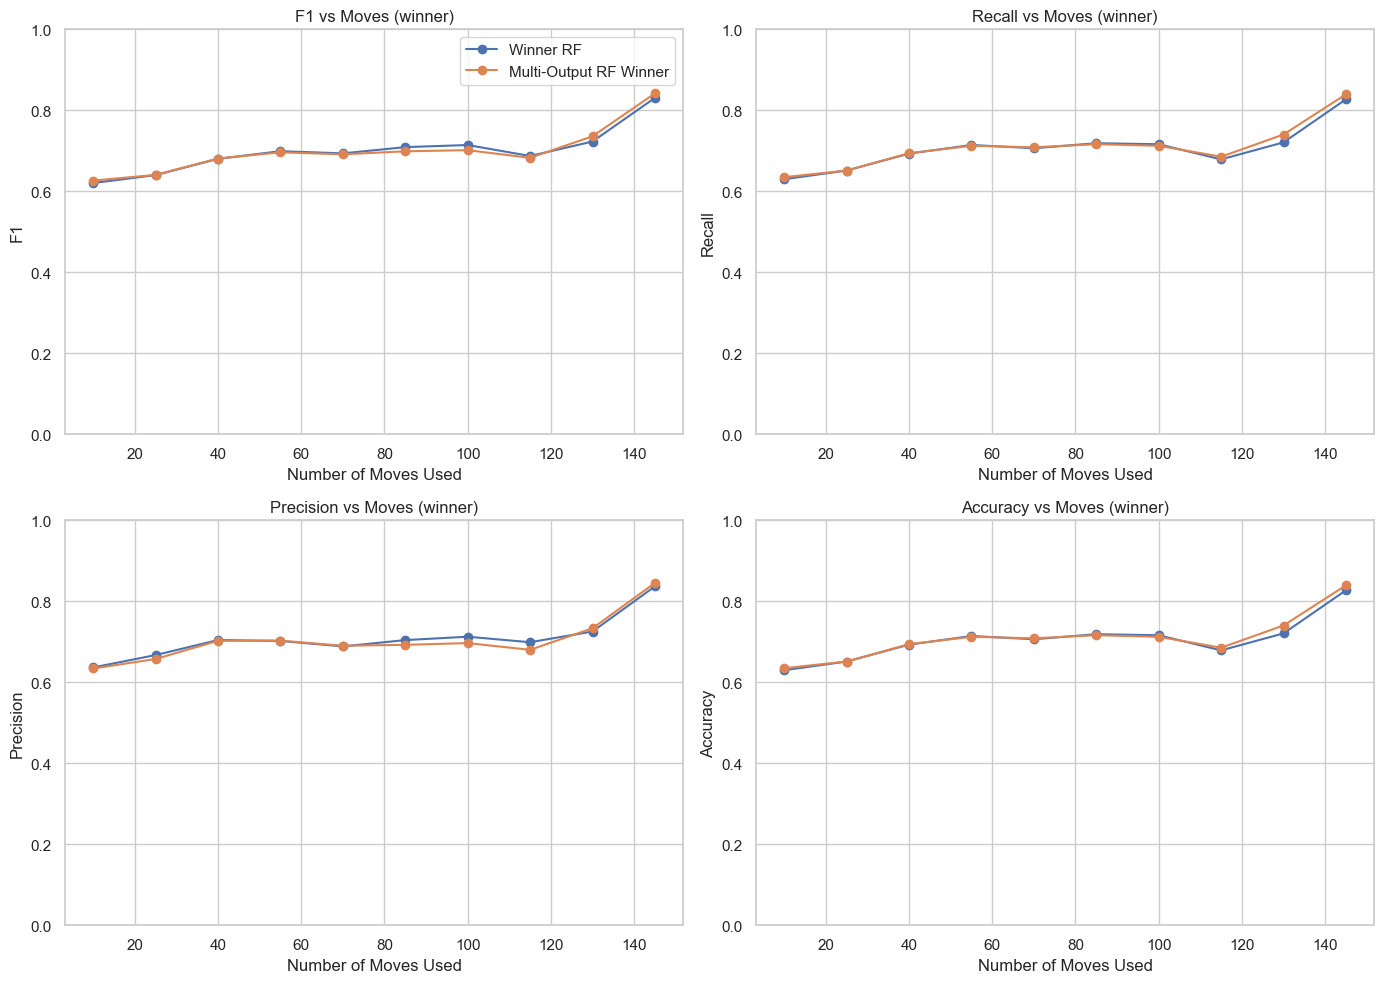

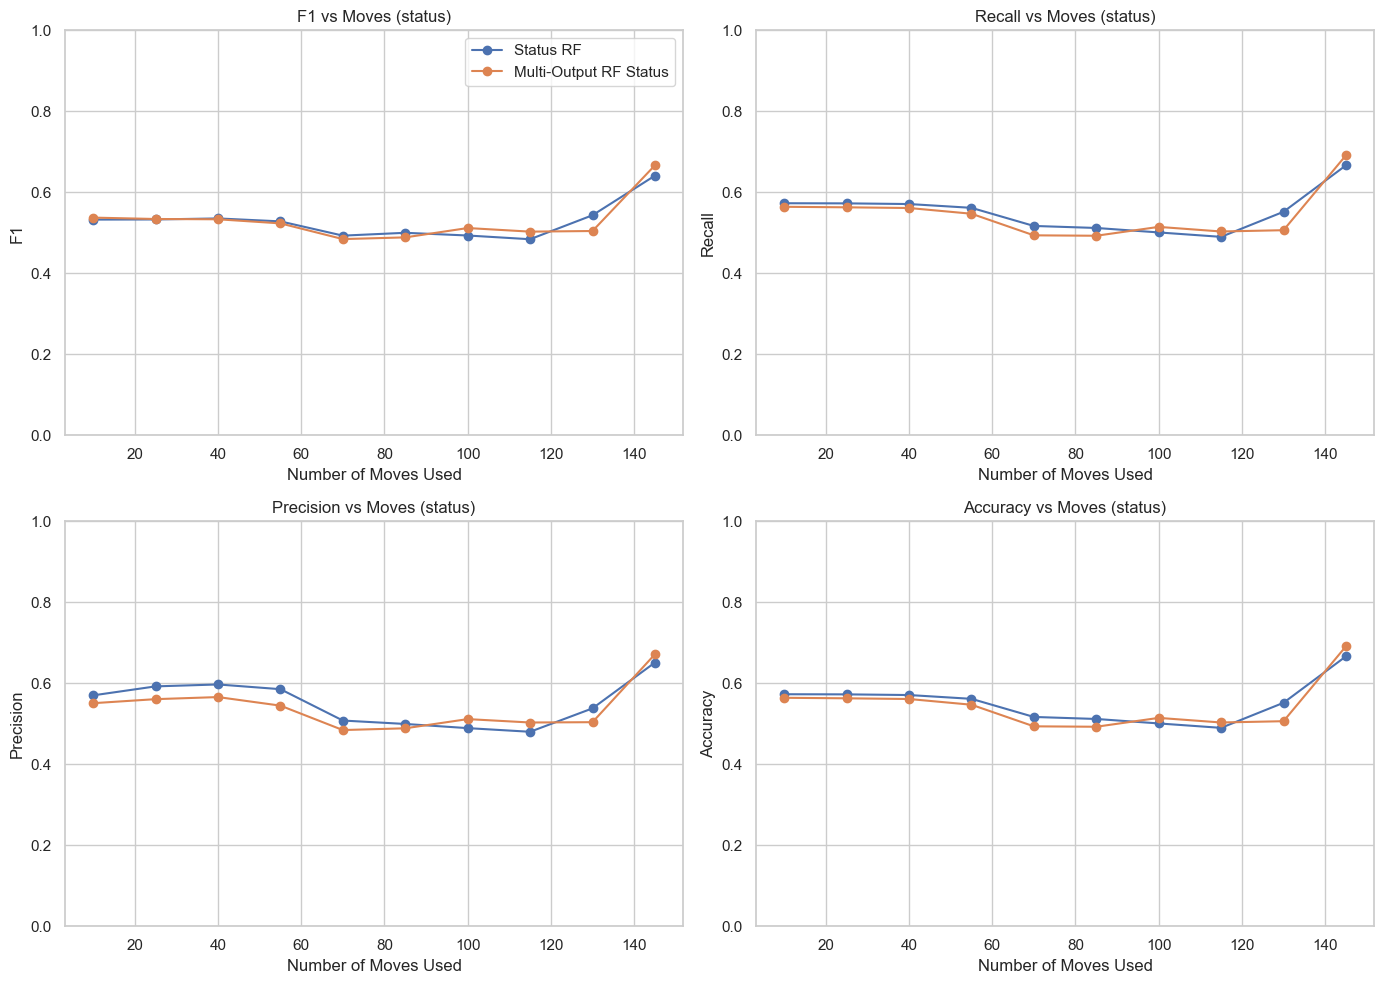

In [8]:
# ============================================================
# Random Forest Evaluation by Move Count with Subplots
# ============================================================

def plot_conf_matrix(y_true, y_pred, model_name, labels=None):
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels
    )

    disp.plot(values_format="d")
    plt.title(model_name)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


rf_results = []

def evaluate_predictions(
    y_true,
    y_pred,
    model_name,
    move_value=None,
    target=None,
    encoder=None,
    make_confusion_matrix=False
):
    if encoder is not None and np.issubdtype(np.asarray(y_pred).dtype, np.number):
        y_pred_labels = encoder.inverse_transform(y_pred)
        y_true_labels = y_true
        labels = list(encoder.classes_)
    else:
        y_pred_labels = y_pred
        y_true_labels = y_true
        labels = sorted(pd.Series(y_true_labels).unique())

    acc = accuracy_score(y_true_labels, y_pred_labels)
    prec = precision_score(y_true_labels, y_pred_labels, average="weighted", zero_division=0)
    rec = recall_score(y_true_labels, y_pred_labels, average="weighted", zero_division=0)
    f1 = f1_score(y_true_labels, y_pred_labels, average="weighted", zero_division=0)

    print(f"\n--- {model_name} ---")
    print("Accuracy:", acc)
    print("Precision weighted:", prec)
    print("Recall weighted:", rec)
    print("F1 weighted:", f1)

    if make_confusion_matrix:
        print("\nClassification Report:")
        print(classification_report(y_true_labels, y_pred_labels, zero_division=0))
        plot_conf_matrix(y_true_labels, y_pred_labels, model_name, labels=labels)

    if move_value is not None and target is not None:
        rf_results.append({
            "model": model_name,
            "target": target,
            "num_moves_used": move_value,
            "f1": f1,
            "recall": rec,
            "precision": prec,
            "accuracy": acc
        })


def validate_all_rf_at_move(move_value, window=3):
    print("\n" + "=" * 70)
    print(f"Random Forest Validation around {move_value} moves (+/- {window})")
    print("=" * 70)

    move_mask = (
        (test_expanded["num_moves_used"] >= move_value - window) &
        (test_expanded["num_moves_used"] <= move_value + window)
    )

    if move_mask.sum() == 0:
        print(f"No test samples found around {move_value} moves.")
        return

    print("Number of snapshots:", move_mask.sum())

    y_winner_move = test_expanded.loc[move_mask, "winner"]
    y_status_move = test_expanded.loc[move_mask, "victory_status"]

    x_winner_move = test_expanded.loc[move_mask, winner_best_features].astype(float)
    x_status_move = test_expanded.loc[move_mask, status_best_features].astype(float)
    x_multi_move = test_expanded.loc[move_mask, multi_best_features].astype(float)

    winner_pred_move = rf_winner_best.predict(x_winner_move)
    status_pred_move = rf_status_best.predict(x_status_move)

    multi_pred_move = rf_multi_best.predict(x_multi_move)
    multi_winner_pred_move = multi_pred_move[:, 0]
    multi_status_pred_move = multi_pred_move[:, 1]

    evaluate_predictions(
        y_winner_move,
        winner_pred_move,
        "Winner RF",
        move_value=move_value,
        target="winner",
        encoder=winner_encoder
    )

    evaluate_predictions(
        y_status_move,
        status_pred_move,
        "Status RF",
        move_value=move_value,
        target="status",
        encoder=status_encoder
    )

    evaluate_predictions(
        y_winner_move,
        multi_winner_pred_move,
        "Multi-Output RF Winner",
        move_value=move_value,
        target="winner",
        encoder=winner_encoder
    )

    evaluate_predictions(
        y_status_move,
        multi_status_pred_move,
        "Multi-Output RF Status",
        move_value=move_value,
        target="status",
        encoder=status_encoder
    )


def plot_all_metrics_by_moves(results_df, target):
    metrics = ["f1", "recall", "precision", "accuracy"]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    target_df = results_df[results_df["target"] == target].copy()

    for i, metric in enumerate(metrics):
        ax = axes[i]

        for model_name in target_df["model"].unique():
            model_df = target_df[target_df["model"] == model_name].sort_values("num_moves_used")

            ax.plot(
                model_df["num_moves_used"],
                model_df[metric],
                marker="o",
                label=model_name
            )

        ax.set_title(f"{metric.capitalize()} vs Moves ({target})")
        ax.set_xlabel("Number of Moves Used")
        ax.set_ylabel(metric.capitalize())
        ax.set_ylim(0, 1)
        ax.grid(True)

    axes[0].legend()
    plt.tight_layout()
    plt.show()


# ============================================================
# Run Move-Based Evaluation
# ============================================================

move_points_to_test = list(range(10, 151, 15))

rf_results = []

for move_value in move_points_to_test:
    validate_all_rf_at_move(move_value, window=3)

rf_results_df = pd.DataFrame(rf_results)
display(rf_results_df)


# ============================================================
# Plot Metrics with Subplots
# ============================================================

plot_all_metrics_by_moves(rf_results_df, target="winner")
plot_all_metrics_by_moves(rf_results_df, target="status")

In [9]:
# ------------------------------------------------------------
# 1. SAN Subtokenization
# ------------------------------------------------------------

def san_to_subtokens(san):
    san = str(san).strip()
    san = san.replace("!", "").replace("?", "")

    if san == "O-O":
        return ["castle_kingside"]
    if san == "O-O-O":
        return ["castle_queenside"]

    tokens = []

    suffix_tokens = []
    while len(san) > 0 and san[-1] in ["+", "#"]:
        if san[-1] == "+":
            suffix_tokens.append("check")
        elif san[-1] == "#":
            suffix_tokens.append("mate")
        san = san[:-1]

    promo_match = re.search(r"=([QRBN])", san)
    if promo_match:
        promo_piece = promo_match.group(1)
        san = re.sub(r"=([QRBN])", "", san)
        promo_token = f"promo_{promo_piece}"
    else:
        promo_token = None

    dest_match = re.search(r"([a-h][1-8])$", san)

    if not dest_match:
        return [f"raw_{san}"] + suffix_tokens

    dest = dest_match.group(1)
    san_core = san[:-2]

    if len(san_core) > 0 and san_core[0] in "KQRBN":
        piece = san_core[0]
        san_core = san_core[1:]
    else:
        piece = "P"

    tokens.append(piece)

    if "x" in san_core:
        before_capture, after_capture = san_core.split("x", 1)

        if before_capture:
            for ch in before_capture:
                tokens.append(f"src_{ch}")

        tokens.append("x")

        if after_capture:
            for ch in after_capture:
                tokens.append(f"hint_{ch}")

    else:
        if san_core:
            for ch in san_core:
                tokens.append(f"src_{ch}")

    tokens.append(f"dst_{dest}")

    if promo_token is not None:
        tokens.append(promo_token)

    tokens.extend(reversed(suffix_tokens))

    return tokens


def move_string_to_subtokens(move_string):
    moves = str(move_string).split()
    all_tokens = []

    for move in moves:
        all_tokens.append("<m>")
        all_tokens.extend(san_to_subtokens(move))

    return " ".join(all_tokens)


def build_move_vectors(train_text, test_text, max_tokens=30000):
    train_lengths = pd.Series(train_text).apply(lambda x: len(str(x).split()))

    sequence_length = int(np.percentile(train_lengths, 95))
    sequence_length = max(sequence_length, 20)

    vectorizer = TextVectorization(
        max_tokens=max_tokens,
        output_mode="int",
        output_sequence_length=sequence_length,
        standardize=None,
        split="whitespace"
    )

    vectorizer.adapt(train_text)

    X_train = vectorizer(train_text).numpy()
    X_test = vectorizer(test_text).numpy()

    vocab_size = len(vectorizer.get_vocabulary())

    return X_train, X_test, vectorizer, vocab_size, sequence_length

# ------------------------------------------------------------
# Build BOTH move text versions
# ------------------------------------------------------------

# Normal tokenized SAN
train_expanded["moves_normal"] = train_expanded["moves_truncated"].astype(str)
test_expanded["moves_normal"] = test_expanded["moves_truncated"].astype(str)

# Subtokenized SAN
train_expanded["moves_subtok"] = train_expanded["moves_truncated"].apply(move_string_to_subtokens)
test_expanded["moves_subtok"] = test_expanded["moves_truncated"].apply(move_string_to_subtokens)


# ------------------------------------------------------------
# NORMAL SAN vectors
# ------------------------------------------------------------

X_moves_train_normal, X_moves_test_normal, normal_vectorizer, normal_vocab_size, normal_seq_len = build_move_vectors(
    train_expanded["moves_normal"].astype(str).values,
    test_expanded["moves_normal"].astype(str).values
)

# ------------------------------------------------------------
# SUBTOKENIZED SAN vectors
# ------------------------------------------------------------

X_moves_train_subtok, X_moves_test_subtok, subtok_vectorizer, subtok_vocab_size, subtok_seq_len = build_move_vectors(
    train_expanded["moves_subtok"].astype(str).values,
    test_expanded["moves_subtok"].astype(str).values
)


# ------------------------------------------------------------
# 4. Extra Numeric Features
# ------------------------------------------------------------

extra_scaler = StandardScaler()

X_extra_train = extra_scaler.fit_transform(X_train_global).astype(np.float32)
X_extra_test = extra_scaler.transform(X_test_global).astype(np.float32)


# ------------------------------------------------------------
# 5. Labels
# ------------------------------------------------------------

y_winner_train_tf = train_expanded["y_winner"].values
y_winner_test_tf = test_expanded["y_winner"].values

y_status_train_tf = train_expanded["y_status"].values
y_status_test_tf = test_expanded["y_status"].values

n_winner_classes = len(winner_encoder.classes_)
n_status_classes = len(status_encoder.classes_)


print("\nNormal SAN:")
print("Sequence length:", normal_seq_len)
print("Vocabulary size:", normal_vocab_size)
print("X shape:", X_moves_train_normal.shape)

print("\nSubtokenized SAN:")
print("Sequence length:", subtok_seq_len)
print("Vocabulary size:", subtok_vocab_size)
print("X shape:", X_moves_train_subtok.shape)

print("\nExtra features shape:", X_extra_train.shape)

print("\nWinner classes:", list(winner_encoder.classes_))
print("Status classes:", list(status_encoder.classes_))


Normal SAN:
Sequence length: 100
Vocabulary size: 3463
X shape: (184180, 100)

Subtokenized SAN:
Sequence length: 341
Vocabulary size: 99
X shape: (184180, 341)

Extra features shape: (184180, 129)

Winner classes: ['black', 'draw', 'white']
Status classes: ['draw', 'mate', 'outoftime', 'resign']


In [10]:
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.token_emb = Embedding(
            input_dim=vocab_size,
            output_dim=embed_dim,
            mask_zero=True
        )
        self.pos_emb = Embedding(
            input_dim=maxlen,
            output_dim=embed_dim
        )

    def call(self, x):
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)

        token_embeddings = self.token_emb(x)

        return token_embeddings + positions

    def compute_mask(self, inputs, mask=None):
        return self.token_emb.compute_mask(inputs)


class MaskedGlobalAveragePooling1D(layers.Layer):
    def call(self, inputs, mask=None):
        if mask is None:
            return tf.reduce_mean(inputs, axis=1)

        mask = tf.cast(mask, inputs.dtype)
        mask = tf.expand_dims(mask, axis=-1)

        masked_inputs = inputs * mask
        sum_inputs = tf.reduce_sum(masked_inputs, axis=1)
        denom = tf.reduce_sum(mask, axis=1)

        return sum_inputs / tf.maximum(denom, tf.ones_like(denom))

    def compute_mask(self, inputs, mask=None):
        return None


class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1, **kwargs):
        super().__init__(**kwargs)

        self.att = MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim // num_heads
        )

        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation="relu"),
            Dense(embed_dim)
        ])

        self.ln1 = LayerNormalization(epsilon=1e-6)
        self.ln2 = LayerNormalization(epsilon=1e-6)

        self.drop1 = Dropout(rate)
        self.drop2 = Dropout(rate)

    def call(self, x, training=False, mask=None):
        attention_mask = None

        if mask is not None:
            attention_mask = tf.cast(mask[:, tf.newaxis, :], dtype=tf.int32)

        attn_output = self.att(
            x,
            x,
            attention_mask=attention_mask,
            training=training
        )

        attn_output = self.drop1(attn_output, training=training)
        out1 = self.ln1(x + attn_output)

        ffn_output = self.ffn(out1)
        ffn_output = self.drop2(ffn_output, training=training)

        return self.ln2(out1 + ffn_output)

    def compute_mask(self, inputs, mask=None):
        return mask



In [11]:
def build_hybrid_winner_only_transformer(
    vocab_size,
    maxlen,
    extra_dim,
    embed_dim=64,
    num_heads=4,
    ff_dim=128,
    num_transformer_blocks=4,
    dropout_rate=0.15
):
    moves_input = Input(shape=(maxlen,), name="moves_input")

    x_seq = TokenAndPositionEmbedding(
        maxlen=maxlen,
        vocab_size=vocab_size,
        embed_dim=embed_dim
    )(moves_input)

    for _ in range(num_transformer_blocks):
        x_seq = TransformerBlock(
            embed_dim=embed_dim,
            num_heads=num_heads,
            ff_dim=ff_dim,
            rate=dropout_rate
        )(x_seq)

    x_seq = MaskedGlobalAveragePooling1D()(x_seq)
    x_seq = Dense(128, activation="relu")(x_seq)
    x_seq = Dropout(dropout_rate)(x_seq)

    extra_input = Input(shape=(extra_dim,), name="extra_input")

    x_extra = Dense(256, activation="relu")(extra_input)
    x_extra = Dropout(0.2)(x_extra)
    x_extra = Dense(128, activation="relu")(x_extra)
    x_extra = Dropout(0.15)(x_extra)
    x_extra = Dense(64, activation="relu")(x_extra)

    x = Concatenate()([x_seq, x_extra])

    x = Dense(256, activation="relu")(x)
    x = Dropout(0.25)(x)
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.15)(x)

    winner_branch = Dense(64, activation="relu")(x)
    winner_branch = Dropout(0.1)(winner_branch)

    winner_output = Dense(
        n_winner_classes,
        activation="softmax",
        name="winner_output"
    )(winner_branch)

    model = Model(
        inputs=[moves_input, extra_input],
        outputs=winner_output
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [12]:
def build_hybrid_status_only_transformer(
    vocab_size,
    maxlen,
    extra_dim,
    embed_dim=64,
    num_heads=4,
    ff_dim=128,
    num_transformer_blocks=4,
    dropout_rate=0.15
):
    moves_input = Input(shape=(maxlen,), name="moves_input")

    x_seq = TokenAndPositionEmbedding(
        maxlen=maxlen,
        vocab_size=vocab_size,
        embed_dim=embed_dim
    )(moves_input)

    for _ in range(num_transformer_blocks):
        x_seq = TransformerBlock(
            embed_dim=embed_dim,
            num_heads=num_heads,
            ff_dim=ff_dim,
            rate=dropout_rate
        )(x_seq)

    x_seq = MaskedGlobalAveragePooling1D()(x_seq)
    x_seq = Dense(128, activation="relu")(x_seq)
    x_seq = Dropout(dropout_rate)(x_seq)

    extra_input = Input(shape=(extra_dim,), name="extra_input")

    x_extra = Dense(256, activation="relu")(extra_input)
    x_extra = Dropout(0.2)(x_extra)
    x_extra = Dense(128, activation="relu")(x_extra)
    x_extra = Dropout(0.15)(x_extra)
    x_extra = Dense(64, activation="relu")(x_extra)

    x = Concatenate()([x_seq, x_extra])

    x = Dense(256, activation="relu")(x)
    x = Dropout(0.25)(x)
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.15)(x)

    status_branch = Dense(64, activation="relu")(x)
    status_branch = Dropout(0.1)(status_branch)

    status_output = Dense(
        n_status_classes,
        activation="softmax",
        name="status_output"
    )(status_branch)

    model = Model(
        inputs=[moves_input, extra_input],
        outputs=status_output
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [13]:
def build_move_only_both_output_transformer(
    vocab_size,
    maxlen,
    extra_dim=None,   # kept only so your existing train_transformer_model can call it
    embed_dim=128,
    num_heads=8,
    ff_dim=256,
    num_transformer_blocks=6,
    dropout_rate=0.20
):
    moves_input = Input(shape=(maxlen,), name="moves_input")

    x = TokenAndPositionEmbedding(
        maxlen=maxlen,
        vocab_size=vocab_size,
        embed_dim=embed_dim
    )(moves_input)

    for _ in range(num_transformer_blocks):
        x = TransformerBlock(
            embed_dim=embed_dim,
            num_heads=num_heads,
            ff_dim=ff_dim,
            rate=dropout_rate
        )(x)

    x = MaskedGlobalAveragePooling1D()(x)

    x = Dense(256, activation="relu")(x)
    x = Dropout(0.30)(x)

    x = Dense(128, activation="relu")(x)
    x = Dropout(0.20)(x)

    winner_branch = Dense(64, activation="relu")(x)
    winner_branch = Dropout(0.15)(winner_branch)

    winner_output = Dense(
        n_winner_classes,
        activation="softmax",
        name="winner_output"
    )(winner_branch)

    status_branch = Dense(64, activation="relu")(x)
    status_branch = Dropout(0.15)(status_branch)

    status_output = Dense(
        n_status_classes,
        activation="softmax",
        name="status_output"
    )(status_branch)

    model = Model(
        inputs=moves_input,
        outputs=[winner_output, status_output]
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss={
            "winner_output": "sparse_categorical_crossentropy",
            "status_output": "sparse_categorical_crossentropy"
        },
        metrics={
            "winner_output": ["accuracy"],
            "status_output": ["accuracy"]
        }
    )

    return model

In [14]:
def build_hybrid_both_output_transformer(
    vocab_size,
    maxlen,
    extra_dim,
    embed_dim=64,
    num_heads=4,
    ff_dim=128,
    num_transformer_blocks=4,
    dropout_rate=0.15
):
    moves_input = Input(shape=(maxlen,), name="moves_input")

    x_seq = TokenAndPositionEmbedding(
        maxlen=maxlen,
        vocab_size=vocab_size,
        embed_dim=embed_dim
    )(moves_input)

    for _ in range(num_transformer_blocks):
        x_seq = TransformerBlock(
            embed_dim=embed_dim,
            num_heads=num_heads,
            ff_dim=ff_dim,
            rate=dropout_rate
        )(x_seq)

    x_seq = MaskedGlobalAveragePooling1D()(x_seq)
    x_seq = Dense(128, activation="relu")(x_seq)
    x_seq = Dropout(dropout_rate)(x_seq)

    extra_input = Input(shape=(extra_dim,), name="extra_input")

    x_extra = Dense(256, activation="relu")(extra_input)
    x_extra = Dropout(0.2)(x_extra)
    x_extra = Dense(128, activation="relu")(x_extra)
    x_extra = Dropout(0.15)(x_extra)
    x_extra = Dense(64, activation="relu")(x_extra)

    x = Concatenate()([x_seq, x_extra])

    x = Dense(256, activation="relu")(x)
    x = Dropout(0.25)(x)
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.15)(x)

    winner_branch = Dense(64, activation="relu")(x)
    winner_branch = Dropout(0.1)(winner_branch)

    winner_output = Dense(
        n_winner_classes,
        activation="softmax",
        name="winner_output"
    )(winner_branch)

    status_branch = Dense(64, activation="relu")(x)
    status_branch = Dropout(0.1)(status_branch)

    status_output = Dense(
        n_status_classes,
        activation="softmax",
        name="status_output"
    )(status_branch)

    model = Model(
        inputs=[moves_input, extra_input],
        outputs=[winner_output, status_output]
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss={
            "winner_output": "sparse_categorical_crossentropy",
            "status_output": "sparse_categorical_crossentropy"
        },
        metrics={
            "winner_output": ["accuracy"],
            "status_output": ["accuracy"]
        }
    )

    return model

In [15]:
# ============================================================
# Move-Only Winner Transformer
# ============================================================

def build_move_only_winner_transformer(
    vocab_size,
    maxlen,
    extra_dim=None,   # kept so train_transformer_model can call it
    embed_dim=128,
    num_heads=8,
    ff_dim=256,
    num_transformer_blocks=6,
    dropout_rate=0.20
):
    moves_input = Input(shape=(maxlen,), name="moves_input")

    x = TokenAndPositionEmbedding(
        maxlen=maxlen,
        vocab_size=vocab_size,
        embed_dim=embed_dim
    )(moves_input)

    for _ in range(num_transformer_blocks):
        x = TransformerBlock(
            embed_dim=embed_dim,
            num_heads=num_heads,
            ff_dim=ff_dim,
            rate=dropout_rate
        )(x)

    x = MaskedGlobalAveragePooling1D()(x)

    x = Dense(256, activation="relu")(x)
    x = Dropout(0.30)(x)

    x = Dense(128, activation="relu")(x)
    x = Dropout(0.20)(x)

    x = Dense(64, activation="relu")(x)
    x = Dropout(0.15)(x)

    winner_output = Dense(
        n_winner_classes,
        activation="softmax",
        name="winner_output"
    )(x)

    model = Model(
        inputs=moves_input,
        outputs=winner_output
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# ============================================================
# Move-Only Status Transformer
# ============================================================

def build_move_only_status_transformer(
    vocab_size,
    maxlen,
    extra_dim=None,   # kept so train_transformer_model can call it
    embed_dim=128,
    num_heads=8,
    ff_dim=256,
    num_transformer_blocks=6,
    dropout_rate=0.20
):
    moves_input = Input(shape=(maxlen,), name="moves_input")

    x = TokenAndPositionEmbedding(
        maxlen=maxlen,
        vocab_size=vocab_size,
        embed_dim=embed_dim
    )(moves_input)

    for _ in range(num_transformer_blocks):
        x = TransformerBlock(
            embed_dim=embed_dim,
            num_heads=num_heads,
            ff_dim=ff_dim,
            rate=dropout_rate
        )(x)

    x = MaskedGlobalAveragePooling1D()(x)

    x = Dense(256, activation="relu")(x)
    x = Dropout(0.30)(x)

    x = Dense(128, activation="relu")(x)
    x = Dropout(0.20)(x)

    x = Dense(64, activation="relu")(x)
    x = Dropout(0.15)(x)

    status_output = Dense(
        n_status_classes,
        activation="softmax",
        name="status_output"
    )(x)

    model = Model(
        inputs=moves_input,
        outputs=status_output
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [16]:
def train_transformer_model(
    build_model_fn,
    X_moves_train,
    X_extra_train=None,
    y_winner_train_tf=None,
    y_status_train_tf=None,
    vocab_size=None,
    seq_len=None,
    model_name="Transformer Model",
    output_type="both",
    epochs=20,
    batch_size=64
):
    print("\n" + "=" * 60)
    print(f"Training: {model_name}")
    print("=" * 60)

    extra_dim = None
    if X_extra_train is not None:
        extra_dim = X_extra_train.shape[1]

    model = build_model_fn(
        vocab_size=vocab_size,
        maxlen=seq_len,
        extra_dim=extra_dim
    )

    # Key change for move-only models
    fit_inputs = X_moves_train if X_extra_train is None else [X_moves_train, X_extra_train]

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    )

    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        min_lr=1e-5
    )

    if output_type == "winner":
        winner_weights_auto = compute_class_weight(
            class_weight="balanced",
            classes=np.unique(y_winner_train_tf),
            y=y_winner_train_tf
        )

        winner_class_weights = {
            i: float(np.sqrt(w)) for i, w in enumerate(winner_weights_auto)
        }

        winner_sample_weights = np.array(
            [winner_class_weights[label] for label in y_winner_train_tf],
            dtype=np.float32
        )

        history = model.fit(
            fit_inputs,
            y_winner_train_tf,
            sample_weight=winner_sample_weights,
            validation_split=0.1,
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[early_stop, reduce_lr],
            verbose=1
        )

    elif output_type == "status":
        status_weights_auto = compute_class_weight(
            class_weight="balanced",
            classes=np.unique(y_status_train_tf),
            y=y_status_train_tf
        )

        status_class_weights = {
            i: float(np.sqrt(w)) for i, w in enumerate(status_weights_auto)
        }

        status_sample_weights = np.array(
            [status_class_weights[label] for label in y_status_train_tf],
            dtype=np.float32
        )

        history = model.fit(
            fit_inputs,
            y_status_train_tf,
            sample_weight=status_sample_weights,
            validation_split=0.1,
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[early_stop, reduce_lr],
            verbose=1
        )

    elif output_type == "both":
        winner_weights_auto = compute_class_weight(
            class_weight="balanced",
            classes=np.unique(y_winner_train_tf),
            y=y_winner_train_tf
        )

        status_weights_auto = compute_class_weight(
            class_weight="balanced",
            classes=np.unique(y_status_train_tf),
            y=y_status_train_tf
        )

        winner_class_weights = {
            i: float(np.sqrt(w)) for i, w in enumerate(winner_weights_auto)
        }

        status_class_weights = {
            i: float(np.sqrt(w)) for i, w in enumerate(status_weights_auto)
        }

        winner_sample_weights = np.array(
            [winner_class_weights[label] for label in y_winner_train_tf],
            dtype=np.float32
        )

        status_sample_weights = np.array(
            [status_class_weights[label] for label in y_status_train_tf],
            dtype=np.float32
        )

        history = model.fit(
            fit_inputs,
            [y_winner_train_tf, y_status_train_tf],
            sample_weight=[winner_sample_weights, status_sample_weights],
            validation_split=0.1,
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[early_stop, reduce_lr],
            verbose=1
        )

    else:
        raise ValueError("output_type must be 'winner', 'status', or 'both'")

    return model, history

In [17]:
# ============================================================
# Train All Transformer Models Correctly
# ============================================================

# ----------------------------
# Move-Only Winner Models
# ----------------------------

winner_move_only_normal, winner_move_only_history_normal = train_transformer_model(
    build_model_fn=build_move_only_winner_transformer,
    X_moves_train=X_moves_train_normal,
    X_extra_train=None,
    y_winner_train_tf=y_winner_train_tf,
    vocab_size=normal_vocab_size,
    seq_len=normal_seq_len,
    model_name="Move-Only Winner Normal SAN",
    output_type="winner"
)

winner_move_only_subtok, winner_move_only_history_subtok = train_transformer_model(
    build_model_fn=build_move_only_winner_transformer,
    X_moves_train=X_moves_train_subtok,
    X_extra_train=None,
    y_winner_train_tf=y_winner_train_tf,
    vocab_size=subtok_vocab_size,
    seq_len=subtok_seq_len,
    model_name="Move-Only Winner Subtokenized SAN",
    output_type="winner"
)


# ----------------------------
# Move-Only Status Models
# ----------------------------

status_move_only_normal, status_move_only_history_normal = train_transformer_model(
    build_model_fn=build_move_only_status_transformer,
    X_moves_train=X_moves_train_normal,
    X_extra_train=None,
    y_status_train_tf=y_status_train_tf,
    vocab_size=normal_vocab_size,
    seq_len=normal_seq_len,
    model_name="Move-Only Status Normal SAN",
    output_type="status"
)

status_move_only_subtok, status_move_only_history_subtok = train_transformer_model(
    build_model_fn=build_move_only_status_transformer,
    X_moves_train=X_moves_train_subtok,
    X_extra_train=None,
    y_status_train_tf=y_status_train_tf,
    vocab_size=subtok_vocab_size,
    seq_len=subtok_seq_len,
    model_name="Move-Only Status Subtokenized SAN",
    output_type="status"
)


# ----------------------------
# Move-Only Both-Output Models
# ----------------------------

both_move_only_normal, both_move_only_history_normal = train_transformer_model(
    build_model_fn=build_move_only_both_output_transformer,
    X_moves_train=X_moves_train_normal,
    X_extra_train=None,
    y_winner_train_tf=y_winner_train_tf,
    y_status_train_tf=y_status_train_tf,
    vocab_size=normal_vocab_size,
    seq_len=normal_seq_len,
    model_name="Move-Only Both-Output Normal SAN",
    output_type="both"
)

both_move_only_subtok, both_move_only_history_subtok = train_transformer_model(
    build_model_fn=build_move_only_both_output_transformer,
    X_moves_train=X_moves_train_subtok,
    X_extra_train=None,
    y_winner_train_tf=y_winner_train_tf,
    y_status_train_tf=y_status_train_tf,
    vocab_size=subtok_vocab_size,
    seq_len=subtok_seq_len,
    model_name="Move-Only Both-Output Subtokenized SAN",
    output_type="both"
)


# ----------------------------
# Hybrid Winner Models
# ----------------------------

winner_hybrid_normal, winner_hybrid_history_normal = train_transformer_model(
    build_model_fn=build_hybrid_winner_only_transformer,
    X_moves_train=X_moves_train_normal,
    X_extra_train=X_extra_train,
    y_winner_train_tf=y_winner_train_tf,
    vocab_size=normal_vocab_size,
    seq_len=normal_seq_len,
    model_name="Hybrid Winner Normal SAN",
    output_type="winner"
)

winner_hybrid_subtok, winner_hybrid_history_subtok = train_transformer_model(
    build_model_fn=build_hybrid_winner_only_transformer,
    X_moves_train=X_moves_train_subtok,
    X_extra_train=X_extra_train,
    y_winner_train_tf=y_winner_train_tf,
    vocab_size=subtok_vocab_size,
    seq_len=subtok_seq_len,
    model_name="Hybrid Winner Subtokenized SAN",
    output_type="winner"
)


# ----------------------------
# Hybrid Status Models
# ----------------------------

status_hybrid_normal, status_hybrid_history_normal = train_transformer_model(
    build_model_fn=build_hybrid_status_only_transformer,
    X_moves_train=X_moves_train_normal,
    X_extra_train=X_extra_train,
    y_status_train_tf=y_status_train_tf,
    vocab_size=normal_vocab_size,
    seq_len=normal_seq_len,
    model_name="Hybrid Status Normal SAN",
    output_type="status"
)

status_hybrid_subtok, status_hybrid_history_subtok = train_transformer_model(
    build_model_fn=build_hybrid_status_only_transformer,
    X_moves_train=X_moves_train_subtok,
    X_extra_train=X_extra_train,
    y_status_train_tf=y_status_train_tf,
    vocab_size=subtok_vocab_size,
    seq_len=subtok_seq_len,
    model_name="Hybrid Status Subtokenized SAN",
    output_type="status"
)


# ----------------------------
# Hybrid Both-Output Models
# ----------------------------

both_hybrid_normal, both_hybrid_history_normal = train_transformer_model(
    build_model_fn=build_hybrid_both_output_transformer,
    X_moves_train=X_moves_train_normal,
    X_extra_train=X_extra_train,
    y_winner_train_tf=y_winner_train_tf,
    y_status_train_tf=y_status_train_tf,
    vocab_size=normal_vocab_size,
    seq_len=normal_seq_len,
    model_name="Hybrid Both-Output Normal SAN",
    output_type="both"
)

both_hybrid_subtok, both_hybrid_history_subtok = train_transformer_model(
    build_model_fn=build_hybrid_both_output_transformer,
    X_moves_train=X_moves_train_subtok,
    X_extra_train=X_extra_train,
    y_winner_train_tf=y_winner_train_tf,
    y_status_train_tf=y_status_train_tf,
    vocab_size=subtok_vocab_size,
    seq_len=subtok_seq_len,
    model_name="Hybrid Both-Output Subtokenized SAN",
    output_type="both"
)


Training: Move-Only Winner Normal SAN

Epoch 1/20
2591/2591 ━━━━━━━━━━━━━━━━━━━━ 635s 242ms/step - accuracy: 0.5049 - loss: 0.9082 - val_accuracy: 0.5336 - val_loss: 0.9135 - learning_rate: 1.0000e-04
Epoch 2/20
2591/2591 ━━━━━━━━━━━━━━━━━━━━ 656s 253ms/step - accuracy: 0.6255 - loss: 0.7059 - val_accuracy: 0.5261 - val_loss: 1.1376 - learning_rate: 1.0000e-04
Epoch 3/20
2591/2591 ━━━━━━━━━━━━━━━━━━━━ 656s 253ms/step - accuracy: 0.6924 - loss: 0.5646 - val_accuracy: 0.5428 - val_loss: 1.4731 - learning_rate: 5.0000e-05

Training: Move-Only Winner Subtokenized SAN
Epoch 1/20
2591/2591 ━━━━━━━━━━━━━━━━━━━━ 4400s 2s/step - accuracy: 0.4638 - loss: 0.9559 - val_accuracy: 0.4843 - val_loss: 0.9030 - learning_rate: 1.0000e-04
Epoch 2/20
2591/2591 ━━━━━━━━━━━━━━━━━━━━ 4398s 2s/step - accuracy: 0.4711 - loss: 0.9268 - val_accuracy: 0.4664 - val_loss: 0.9160 - learning_rate: 1.0000e-04
Epoch 3/20
2591/2591 ━━━━━━━━━━━━━━━━━━━━ 4380s 2s/step - accuracy: 0.4863 - loss: 0.8649 - val_accuracy: 0.4

Hybrid Both-Output Normal SAN | 10 moves (+/- 3) | samples = 3872
Hybrid Both-Output Normal SAN | 25 moves (+/- 3) | samples = 3490
Hybrid Both-Output Normal SAN | 40 moves (+/- 3) | samples = 2854
Hybrid Both-Output Normal SAN | 55 moves (+/- 3) | samples = 1992
Hybrid Both-Output Normal SAN | 70 moves (+/- 3) | samples = 1294
Hybrid Both-Output Normal SAN | 85 moves (+/- 3) | samples = 832
Hybrid Both-Output Normal SAN | 100 moves (+/- 3) | samples = 511
Hybrid Both-Output Normal SAN | 115 moves (+/- 3) | samples = 302
Hybrid Both-Output Normal SAN | 130 moves (+/- 3) | samples = 154
Hybrid Both-Output Normal SAN | 145 moves (+/- 3) | samples = 81
Hybrid Both-Output Subtokenized SAN | 10 moves (+/- 3) | samples = 3872
Hybrid Both-Output Subtokenized SAN | 25 moves (+/- 3) | samples = 3490
Hybrid Both-Output Subtokenized SAN | 40 moves (+/- 3) | samples = 2854
Hybrid Both-Output Subtokenized SAN | 55 moves (+/- 3) | samples = 1992
Hybrid Both-Output Subtokenized SAN | 70 moves (+/- 3)

C:\Users\brenn\AppData\Roaming\Python\Python311\site-packages\keras\src\models\functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: moves_input
Received: inputs=['Tensor(shape=(32, 100))']
  warnings.warn(msg)


Move-Only Both-Output Normal SAN | 10 moves (+/- 3) | samples = 3872


C:\Users\brenn\AppData\Roaming\Python\Python311\site-packages\keras\src\models\functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: moves_input
Received: inputs=['Tensor(shape=(None, 100))']
  warnings.warn(msg)


Move-Only Both-Output Normal SAN | 25 moves (+/- 3) | samples = 3490
Move-Only Both-Output Normal SAN | 40 moves (+/- 3) | samples = 2854
Move-Only Both-Output Normal SAN | 55 moves (+/- 3) | samples = 1992
Move-Only Both-Output Normal SAN | 70 moves (+/- 3) | samples = 1294
Move-Only Both-Output Normal SAN | 85 moves (+/- 3) | samples = 832
Move-Only Both-Output Normal SAN | 100 moves (+/- 3) | samples = 511
Move-Only Both-Output Normal SAN | 115 moves (+/- 3) | samples = 302
Move-Only Both-Output Normal SAN | 130 moves (+/- 3) | samples = 154
Move-Only Both-Output Normal SAN | 145 moves (+/- 3) | samples = 81


...

C:\Users\brenn\AppData\Roaming\Python\Python311\site-packages\keras\src\models\functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: moves_input
Received: inputs=['Tensor(shape=(32, 341))']
  warnings.warn(msg)


Move-Only Status Subtokenized SAN | 10 moves (+/- 3) | samples = 3872


C:\Users\brenn\AppData\Roaming\Python\Python311\site-packages\keras\src\models\functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: moves_input
Received: inputs=['Tensor(shape=(None, 341))']
  warnings.warn(msg)


Move-Only Status Subtokenized SAN | 25 moves (+/- 3) | samples = 3490
Move-Only Status Subtokenized SAN | 40 moves (+/- 3) | samples = 2854
Move-Only Status Subtokenized SAN | 55 moves (+/- 3) | samples = 1992
Move-Only Status Subtokenized SAN | 70 moves (+/- 3) | samples = 1294
Move-Only Status Subtokenized SAN | 85 moves (+/- 3) | samples = 832
Move-Only Status Subtokenized SAN | 100 moves (+/- 3) | samples = 511
Move-Only Status Subtokenized SAN | 115 moves (+/- 3) | samples = 302
Move-Only Status Subtokenized SAN | 130 moves (+/- 3) | samples = 154
Move-Only Status Subtokenized SAN | 145 moves (+/- 3) | samples = 81


,model,representation,target,num_moves_used,accuracy,precision,recall,f1
0,Hybrid Both-Output Normal SAN,normal,winner,10,0.621384,0.599194,0.621384,0.608237
1,Hybrid Both-Output Normal SAN,normal,status,10,0.539514,0.459233,0.539514,0.422047
2,Hybrid Both-Output Normal SAN,normal,winner,25,0.622063,0.610740,0.622063,0.615833
3,Hybrid Both-Output Normal SAN,normal,status,25,0.522923,0.460007,0.522923,0.438784
4,Hybrid Both-Output Normal SAN,normal,winner,40,0.653819,0.642383,0.653819,0.647706
...,...,...,...,...,...,...,...,...
115,Move-Only Status Subtokenized SAN,subtok,status,85,0.375000,0.388670,0.375000,0.211831
116,Move-Only Status Subtokenized SAN,subtok,status,100,0.399217,0.162527,0.399217,0.231008
117,Move-Only Status Subtokenized SAN,subtok,status,115,0.420530,0.182654,0.420530,0.254687
118,Move-Only Status Subtokenized SAN,subtok,status,130,0.448052,0.206340,0.448052,0.282555


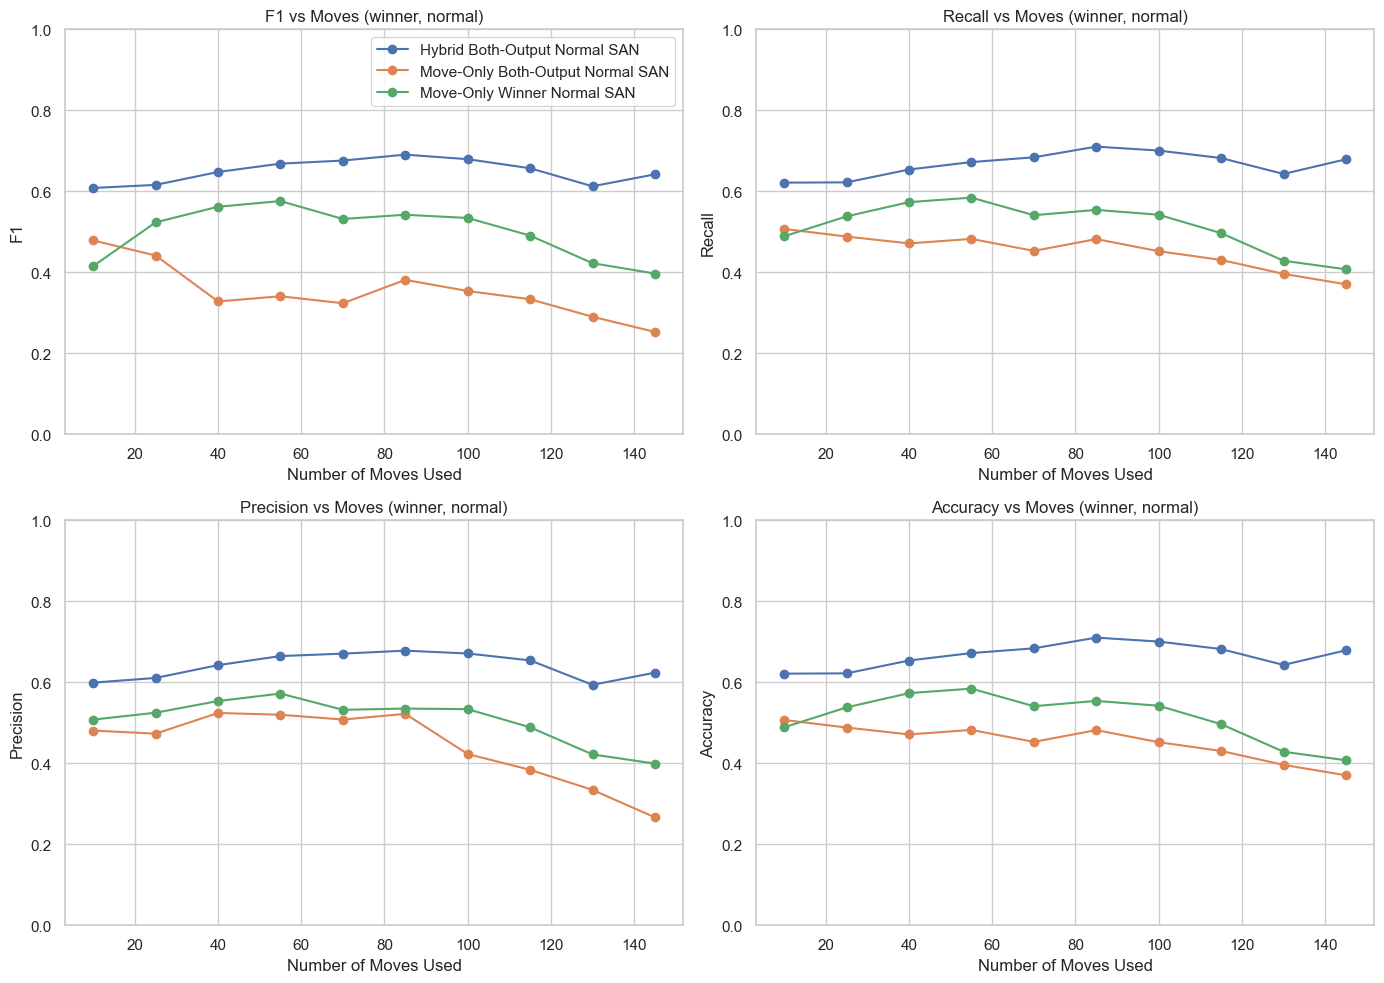

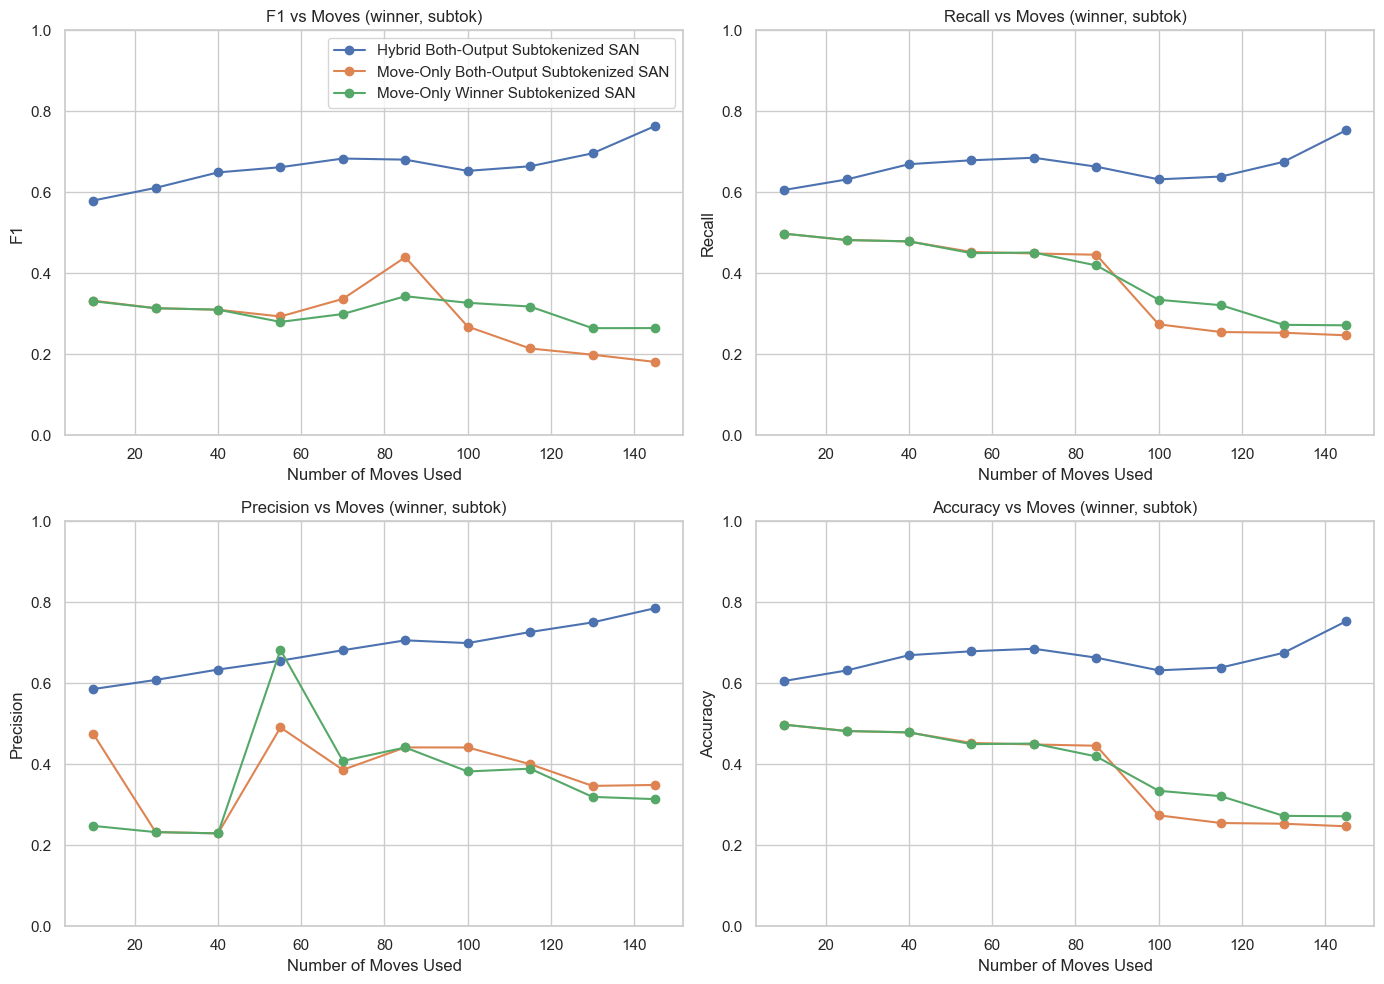

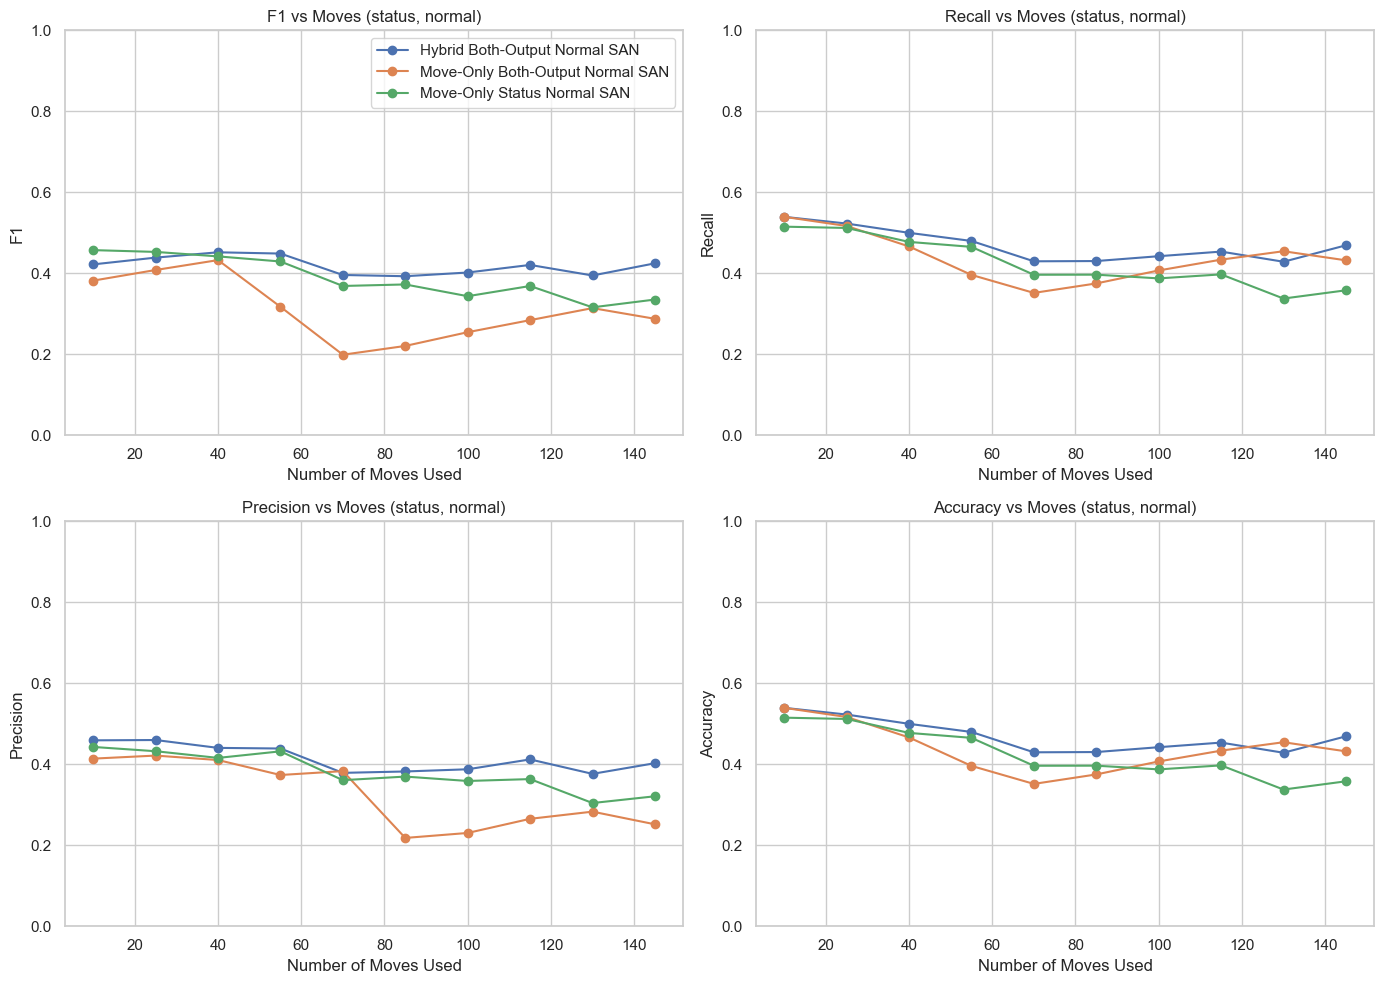

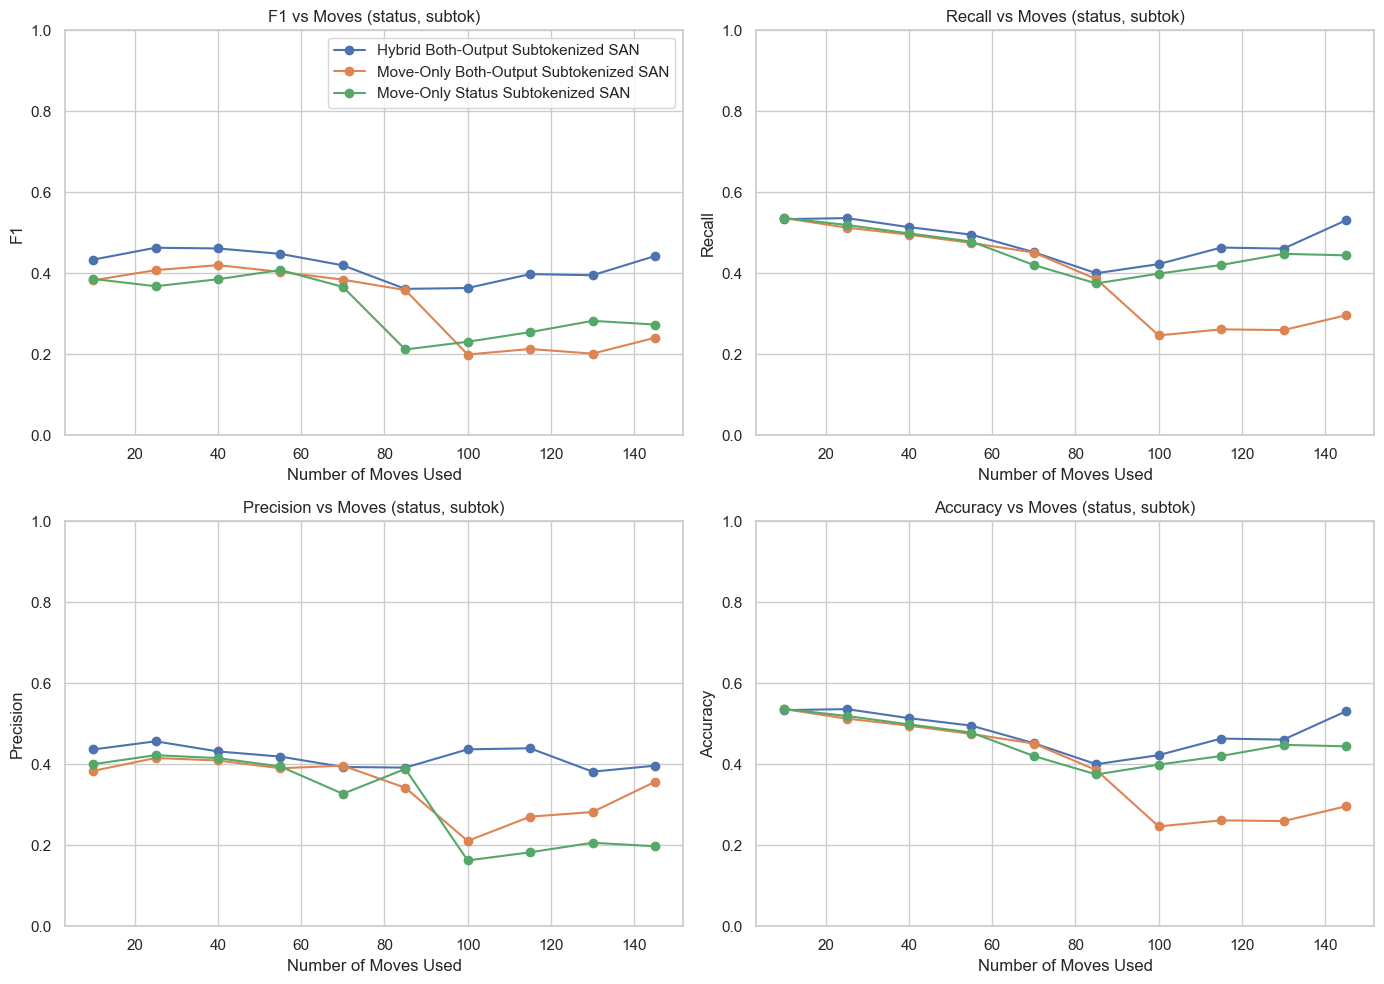

In [ ]:
# ============================================================
# Transformer Evaluation by Move Count with Subplots
# ============================================================

def get_weighted_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1": f1_score(y_true, y_pred, average="weighted", zero_division=0)
    }


def build_transformer_phase_data(move_value, vectorizer, representation="subtok", window=3):
    phase_df = test_expanded[
        (test_expanded["num_moves_used"] >= move_value - window) &
        (test_expanded["num_moves_used"] <= move_value + window)
    ].copy()

    if len(phase_df) == 0:
        return phase_df, None, None, None, None

    if representation == "subtok":
        phase_df["moves_eval"] = phase_df["moves_truncated"].apply(move_string_to_subtokens)
    elif representation == "normal":
        phase_df["moves_eval"] = phase_df["moves_truncated"].astype(str)
    else:
        raise ValueError("representation must be 'normal' or 'subtok'")

    X_moves_phase = vectorizer(phase_df["moves_eval"].astype(str).values).numpy()

    X_extra_phase = extra_scaler.transform(
        phase_df[feature_cols].astype(float)
    ).astype(np.float32)

    y_winner_phase = phase_df["y_winner"].values
    y_status_phase = phase_df["y_status"].values

    return phase_df, X_moves_phase, X_extra_phase, y_winner_phase, y_status_phase


transformer_results = []

def evaluate_transformer_at_move(
    move_value,
    model,
    vectorizer,
    representation,
    model_label,
    output_type="both",
    window=3,
    use_extra=True
):
    phase_df, X_moves_phase, X_extra_phase, y_winner_phase, y_status_phase = (
        build_transformer_phase_data(
            move_value=move_value,
            vectorizer=vectorizer,
            representation=representation,
            window=window
        )
    )

    if len(phase_df) == 0:
        print(f"No test samples found around {move_value} moves.")
        return

    if use_extra:
        predict_inputs = {
            "moves_input": X_moves_phase,
            "extra_input": X_extra_phase
        }
    else:
        predict_inputs = {
            "moves_input": X_moves_phase
        }

    preds = model.predict(
        predict_inputs,
        verbose=0
    )

    print(f"{model_label} | {move_value} moves (+/- {window}) | samples = {len(phase_df)}")

    if output_type == "winner":
        winner_pred = np.argmax(preds, axis=1)
        winner_metrics = get_weighted_metrics(y_winner_phase, winner_pred)

        transformer_results.append({
            "model": model_label,
            "representation": representation,
            "target": "winner",
            "num_moves_used": move_value,
            **winner_metrics
        })

    elif output_type == "status":
        status_pred = np.argmax(preds, axis=1)
        status_metrics = get_weighted_metrics(y_status_phase, status_pred)

        transformer_results.append({
            "model": model_label,
            "representation": representation,
            "target": "status",
            "num_moves_used": move_value,
            **status_metrics
        })

    elif output_type == "both":
        winner_pred_probs, status_pred_probs = preds

        winner_pred = np.argmax(winner_pred_probs, axis=1)
        status_pred = np.argmax(status_pred_probs, axis=1)

        winner_metrics = get_weighted_metrics(y_winner_phase, winner_pred)
        status_metrics = get_weighted_metrics(y_status_phase, status_pred)

        transformer_results.append({
            "model": model_label,
            "representation": representation,
            "target": "winner",
            "num_moves_used": move_value,
            **winner_metrics
        })

        transformer_results.append({
            "model": model_label,
            "representation": representation,
            "target": "status",
            "num_moves_used": move_value,
            **status_metrics
        })

    else:
        raise ValueError("output_type must be 'winner', 'status', or 'both'")


def plot_transformer_all_metrics_by_moves(results_df, target, representation):
    metrics = ["f1", "recall", "precision", "accuracy"]

    plot_df = results_df[
        (results_df["target"] == target) &
        (results_df["representation"] == representation)
    ].copy()

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for i, metric in enumerate(metrics):
        ax = axes[i]

        for model_name in plot_df["model"].unique():
            model_df = plot_df[
                plot_df["model"] == model_name
            ].sort_values("num_moves_used")

            ax.plot(
                model_df["num_moves_used"],
                model_df[metric],
                marker="o",
                label=model_name
            )

        ax.set_title(f"{metric.capitalize()} vs Moves ({target}, {representation})")
        ax.set_xlabel("Number of Moves Used")
        ax.set_ylabel(metric.capitalize())
        ax.set_ylim(0, 1)
        ax.grid(True)

    axes[0].legend()
    plt.tight_layout()
    plt.show()


# ============================================================
# Run Transformer Move-Based Evaluation
# ============================================================

move_points_to_test = list(range(10, 151, 15))
window = 3

models_to_evaluate = [
    {
        "model": both_hybrid_normal,
        "vectorizer": normal_vectorizer,
        "representation": "normal",
        "label": "Hybrid Both-Output Normal SAN",
        "output_type": "both",
        "use_extra": True
    },
    {
        "model": both_hybrid_subtok,
        "vectorizer": subtok_vectorizer,
        "representation": "subtok",
        "label": "Hybrid Both-Output Subtokenized SAN",
        "output_type": "both",
        "use_extra": True
    },

    {
        "model": both_move_only_normal,
        "vectorizer": normal_vectorizer,
        "representation": "normal",
        "label": "Move-Only Both-Output Normal SAN",
        "output_type": "both",
        "use_extra": False
    },
    {
        "model": both_move_only_subtok,
        "vectorizer": subtok_vectorizer,
        "representation": "subtok",
        "label": "Move-Only Both-Output Subtokenized SAN",
        "output_type": "both",
        "use_extra": False
    },

    {
        "model": winner_move_only_normal,
        "vectorizer": normal_vectorizer,
        "representation": "normal",
        "label": "Move-Only Winner Normal SAN",
        "output_type": "winner",
        "use_extra": False
    },
    {
        "model": winner_move_only_subtok,
        "vectorizer": subtok_vectorizer,
        "representation": "subtok",
        "label": "Move-Only Winner Subtokenized SAN",
        "output_type": "winner",
        "use_extra": False
    },

    {
        "model": status_move_only_normal,
        "vectorizer": normal_vectorizer,
        "representation": "normal",
        "label": "Move-Only Status Normal SAN",
        "output_type": "status",
        "use_extra": False
    },
    {
        "model": status_move_only_subtok,
        "vectorizer": subtok_vectorizer,
        "representation": "subtok",
        "label": "Move-Only Status Subtokenized SAN",
        "output_type": "status",
        "use_extra": False
    },
]

transformer_results = []

for model_info in models_to_evaluate:
    for move_value in move_points_to_test:
        evaluate_transformer_at_move(
            move_value=move_value,
            model=model_info["model"],
            vectorizer=model_info["vectorizer"],
            representation=model_info["representation"],
            model_label=model_info["label"],
            output_type=model_info["output_type"],
            window=window,
            use_extra=model_info["use_extra"]
        )

transformer_results_df = pd.DataFrame(transformer_results)
display(transformer_results_df)


# ============================================================
# Plot Transformer Metrics with Subplots
# ============================================================

plot_transformer_all_metrics_by_moves(transformer_results_df, "winner", "normal")
plot_transformer_all_metrics_by_moves(transformer_results_df, "winner", "subtok")
plot_transformer_all_metrics_by_moves(transformer_results_df, "status", "normal")
plot_transformer_all_metrics_by_moves(transformer_results_df, "status", "subtok")

,model_family,model,representation,target,num_moves_used,accuracy,precision,recall,f1
0,Random Forest,Winner RF,feature-based,winner,10,0.629907,0.636722,0.629907,0.620478
1,Random Forest,Status RF,feature-based,status,10,0.573089,0.570361,0.573089,0.532691
2,Random Forest,Multi-Output RF Winner,feature-based,winner,10,0.634814,0.634091,0.634814,0.626490
3,Random Forest,Multi-Output RF Status,feature-based,status,10,0.564308,0.551002,0.564308,0.537582
4,Random Forest,Winner RF,feature-based,winner,25,0.651289,0.667260,0.651289,0.639981
...,...,...,...,...,...,...,...,...,...
155,Transformer,Move-Only Status Subtokenized SAN,subtok,status,85,0.375000,0.388670,0.375000,0.211831
156,Transformer,Move-Only Status Subtokenized SAN,subtok,status,100,0.399217,0.162527,0.399217,0.231008
157,Transformer,Move-Only Status Subtokenized SAN,subtok,status,115,0.420530,0.182654,0.420530,0.254687
158,Transformer,Move-Only Status Subtokenized SAN,subtok,status,130,0.448052,0.206340,0.448052,0.282555



Overall model ranking by average F1:


,target,model_family,model,representation,mean_f1,mean_accuracy,mean_precision,mean_recall,best_f1,worst_f1,std_f1
0,status,Random Forest,Multi-Output RF Status,feature-based,0.528793,0.543830,0.538739,0.543830,0.666744,0.484565,0.051953
1,status,Random Forest,Status RF,feature-based,0.528497,0.551742,0.551286,0.551742,0.641244,0.484188,0.045069
2,status,Transformer,Hybrid Both-Output Normal SAN,normal,0.419217,0.469594,0.413908,0.469594,0.451911,0.392800,0.022385
3,status,Transformer,Hybrid Both-Output Subtokenized SAN,subtok,0.418724,0.481023,0.418457,0.481023,0.463206,0.361597,0.037613
6,status,Transformer,Move-Only Status Normal SAN,normal,0.388576,0.424380,0.380142,0.424380,0.457299,0.315956,0.052225
5,status,Transformer,Move-Only Both-Output Subtokenized SAN,subtok,0.321213,0.392099,0.345821,0.392099,0.420166,0.199406,0.094603
7,status,Transformer,Move-Only Status Subtokenized SAN,subtok,0.316783,0.454082,0.309766,0.454082,0.408129,0.211831,0.073210
4,status,Transformer,Move-Only Both-Output Normal SAN,normal,0.310009,0.437295,0.325181,0.437295,0.432647,0.198867,0.077822
9,winner,Random Forest,Winner RF,feature-based,0.699756,0.705669,0.707712,0.705669,0.830678,0.620478,0.056188
8,winner,Random Forest,Multi-Output RF Winner,feature-based,0.699639,0.709509,0.703556,0.709509,0.841793,0.626490,0.058770



Best model per prediction target:


,target,model_family,model,representation,mean_f1,mean_accuracy,mean_precision,mean_recall,best_f1,worst_f1,std_f1
0,status,Random Forest,Multi-Output RF Status,feature-based,0.528793,0.543830,0.538739,0.543830,0.666744,0.484565,0.051953
1,winner,Random Forest,Winner RF,feature-based,0.699756,0.705669,0.707712,0.705669,0.830678,0.620478,0.056188


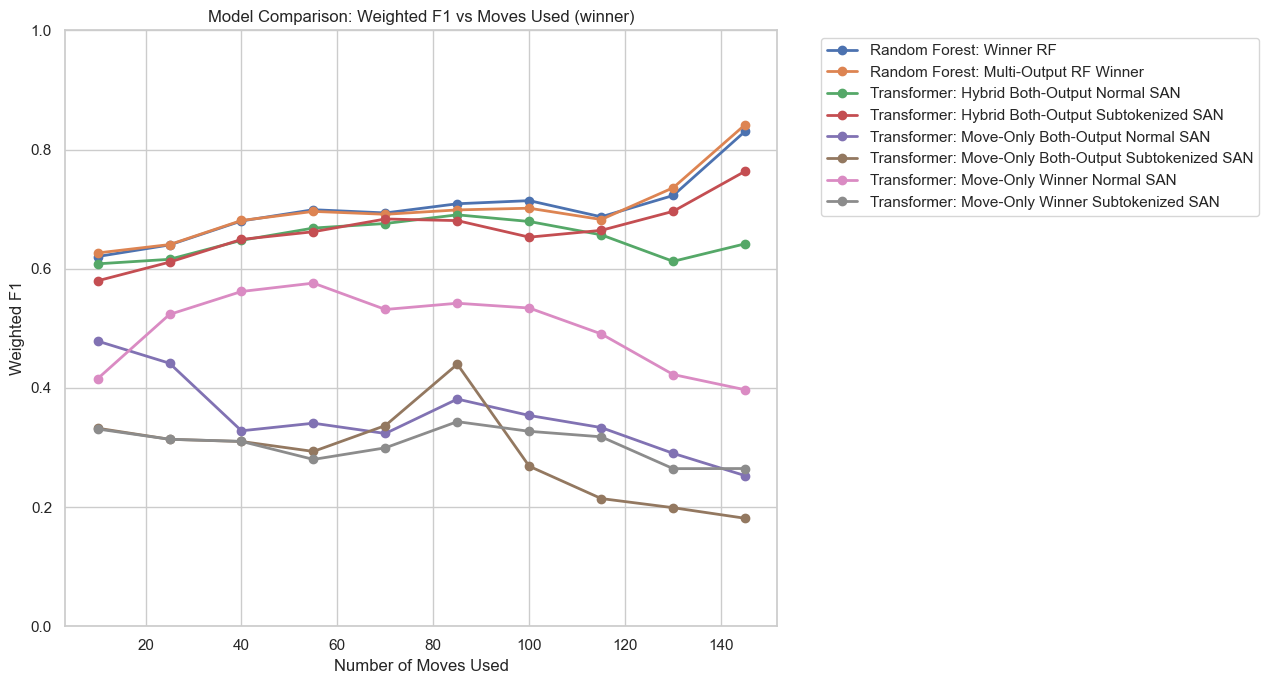

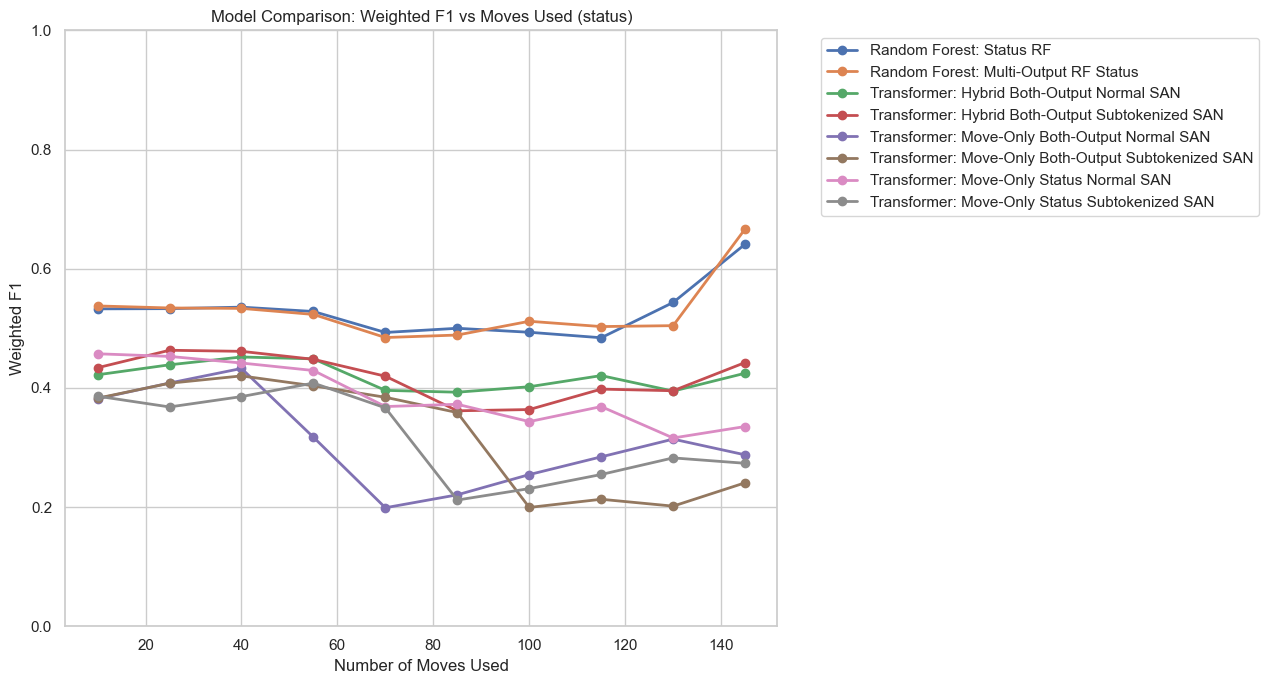

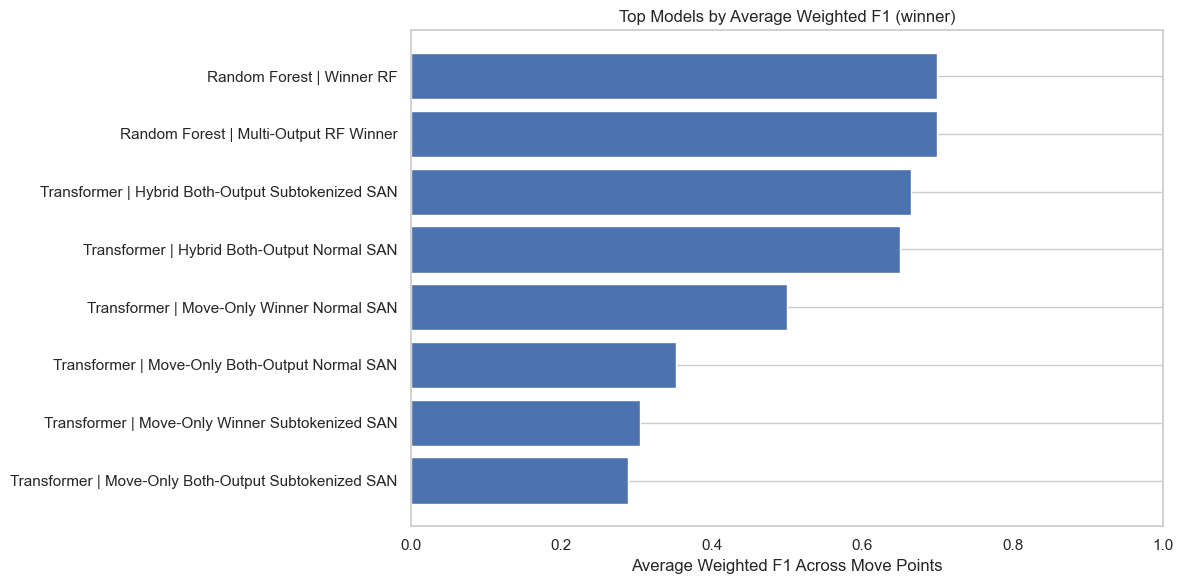

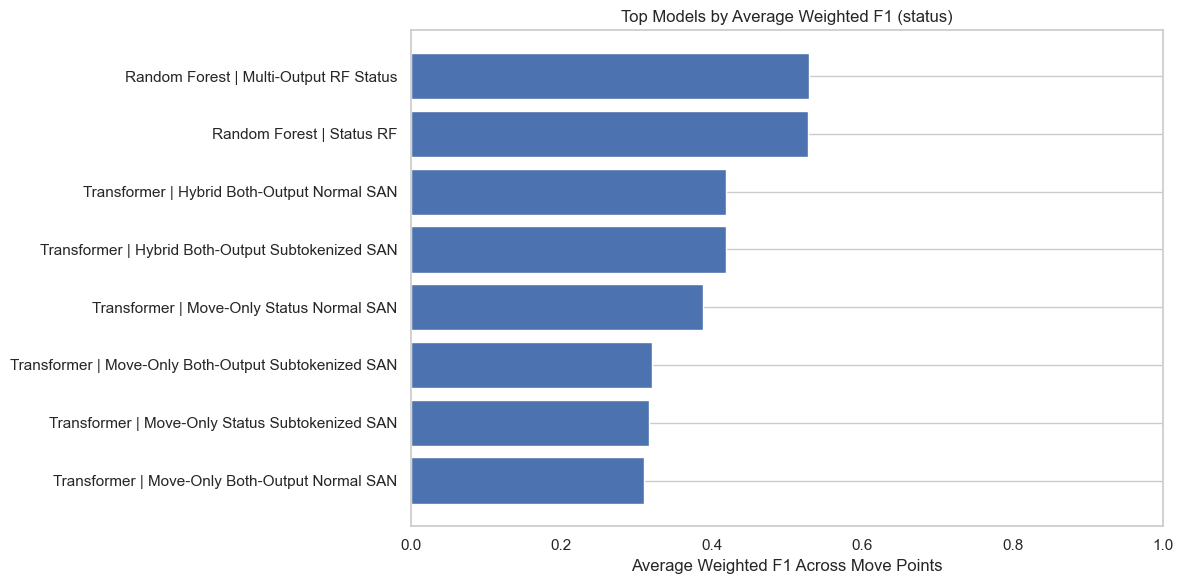


Model ranking using stability score = mean F1 - std F1:


,target,model_family,model,representation,mean_f1,mean_accuracy,mean_precision,mean_recall,best_f1,worst_f1,std_f1,stability_score
1,status,Random Forest,Status RF,feature-based,0.528497,0.551742,0.551286,0.551742,0.641244,0.484188,0.045069,0.483429
0,status,Random Forest,Multi-Output RF Status,feature-based,0.528793,0.543830,0.538739,0.543830,0.666744,0.484565,0.051953,0.476839
2,status,Transformer,Hybrid Both-Output Normal SAN,normal,0.419217,0.469594,0.413908,0.469594,0.451911,0.392800,0.022385,0.396832
3,status,Transformer,Hybrid Both-Output Subtokenized SAN,subtok,0.418724,0.481023,0.418457,0.481023,0.463206,0.361597,0.037613,0.381111
6,status,Transformer,Move-Only Status Normal SAN,normal,0.388576,0.424380,0.380142,0.424380,0.457299,0.315956,0.052225,0.336351
7,status,Transformer,Move-Only Status Subtokenized SAN,subtok,0.316783,0.454082,0.309766,0.454082,0.408129,0.211831,0.073210,0.243572
4,status,Transformer,Move-Only Both-Output Normal SAN,normal,0.310009,0.437295,0.325181,0.437295,0.432647,0.198867,0.077822,0.232187
5,status,Transformer,Move-Only Both-Output Subtokenized SAN,subtok,0.321213,0.392099,0.345821,0.392099,0.420166,0.199406,0.094603,0.226610
9,winner,Random Forest,Winner RF,feature-based,0.699756,0.705669,0.707712,0.705669,0.830678,0.620478,0.056188,0.643568
8,winner,Random Forest,Multi-Output RF Winner,feature-based,0.699639,0.709509,0.703556,0.709509,0.841793,0.626490,0.058770,0.640868



Best model for STATUS prediction:
Model family: Random Forest
Model: Multi-Output RF Status
Representation: feature-based
Average F1: 0.5288
Best F1: 0.6667
Worst F1: 0.4846
F1 Std Dev: 0.0520

Best model for WINNER prediction:
Model family: Random Forest
Model: Winner RF
Representation: feature-based
Average F1: 0.6998
Best F1: 0.8307
Worst F1: 0.6205
F1 Std Dev: 0.0562


In [22]:

rf_compare_df = rf_results_df.copy()
rf_compare_df["model_family"] = "Random Forest"
rf_compare_df["representation"] = "feature-based"

transformer_compare_df = transformer_results_df.copy()
transformer_compare_df["model_family"] = "Transformer"

# Make sure both tables have the same columns
common_cols = [
    "model_family",
    "model",
    "representation",
    "target",
    "num_moves_used",
    "accuracy",
    "precision",
    "recall",
    "f1"
]

combined_results_df = pd.concat(
    [
        rf_compare_df[common_cols],
        transformer_compare_df[common_cols]
    ],
    ignore_index=True
)

display(combined_results_df)


# ------------------------------------------------------------
# 2. Summary Table: Average Performance Across Game
# ------------------------------------------------------------

summary_df = (
    combined_results_df
    .groupby(["target", "model_family", "model", "representation"], as_index=False)
    .agg(
        mean_f1=("f1", "mean"),
        mean_accuracy=("accuracy", "mean"),
        mean_precision=("precision", "mean"),
        mean_recall=("recall", "mean"),
        best_f1=("f1", "max"),
        worst_f1=("f1", "min"),
        std_f1=("f1", "std")
    )
    .sort_values(["target", "mean_f1"], ascending=[True, False])
)

print("\nOverall model ranking by average F1:")
display(summary_df)


# ------------------------------------------------------------
# 3. Best Model Per Target
# ------------------------------------------------------------

best_models_df = (
    summary_df
    .sort_values(["target", "mean_f1"], ascending=[True, False])
    .groupby("target")
    .head(1)
    .reset_index(drop=True)
)

print("\nBest model per prediction target:")
display(best_models_df)


# ------------------------------------------------------------
# 4. Plot: F1 vs Move Count for Winner and Status
# ------------------------------------------------------------

def plot_combined_f1_by_moves(results_df, target):
    plot_df = results_df[results_df["target"] == target].copy()

    plt.figure(figsize=(13, 7))

    for model_name in plot_df["model"].unique():
        model_df = plot_df[
            plot_df["model"] == model_name
        ].sort_values("num_moves_used")

        family = model_df["model_family"].iloc[0]

        label = f"{family}: {model_name}"

        plt.plot(
            model_df["num_moves_used"],
            model_df["f1"],
            marker="o",
            linewidth=2,
            label=label
        )

    plt.title(f"Model Comparison: Weighted F1 vs Moves Used ({target})")
    plt.xlabel("Number of Moves Used")
    plt.ylabel("Weighted F1")
    plt.ylim(0, 1)
    plt.grid(True)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


plot_combined_f1_by_moves(combined_results_df, target="winner")
plot_combined_f1_by_moves(combined_results_df, target="status")


# ------------------------------------------------------------
# 5. Plot: Average F1 Ranking Bar Chart
# ------------------------------------------------------------

def plot_average_f1_ranking(summary_df, target, top_n=10):
    plot_df = (
        summary_df[summary_df["target"] == target]
        .sort_values("mean_f1", ascending=False)
        .head(top_n)
        .copy()
    )

    plot_df["plot_label"] = (
        plot_df["model_family"] + " | " + plot_df["model"]
    )

    plt.figure(figsize=(12, 6))
    plt.barh(plot_df["plot_label"], plot_df["mean_f1"])
    plt.gca().invert_yaxis()

    plt.title(f"Top Models by Average Weighted F1 ({target})")
    plt.xlabel("Average Weighted F1 Across Move Points")
    plt.xlim(0, 1)
    plt.grid(axis="x")
    plt.tight_layout()
    plt.show()


plot_average_f1_ranking(summary_df, target="winner", top_n=10)
plot_average_f1_ranking(summary_df, target="status", top_n=10)


# ------------------------------------------------------------
# 6. Optional: Stability Score
# Lower std_f1 means the model is more consistent across game stages.
# ------------------------------------------------------------

summary_df["stability_score"] = summary_df["mean_f1"] - summary_df["std_f1"].fillna(0)

stability_ranking_df = (
    summary_df
    .sort_values(["target", "stability_score"], ascending=[True, False])
)

print("\nModel ranking using stability score = mean F1 - std F1:")
display(stability_ranking_df)


# ------------------------------------------------------------
# 7. Claim Helper
# ------------------------------------------------------------

for target in best_models_df["target"].unique():
    row = best_models_df[best_models_df["target"] == target].iloc[0]

    print("\n" + "=" * 70)
    print(f"Best model for {target.upper()} prediction:")
    print("=" * 70)
    print(f"Model family: {row['model_family']}")
    print(f"Model: {row['model']}")
    print(f"Representation: {row['representation']}")
    print(f"Average F1: {row['mean_f1']:.4f}")
    print(f"Best F1: {row['best_f1']:.4f}")
    print(f"Worst F1: {row['worst_f1']:.4f}")
    print(f"F1 Std Dev: {row['std_f1']:.4f}")